In [1]:
import numpy as np
np.set_printoptions(threshold=np.inf)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from scipy.stats import norm

from GPDFlow_S import S_mGPD_NF, ConditionalMaskedAffineFlow, ActNormConditional, ConditionalNormalizingFlow
import Common_Functions as cf
from matplotlib.colors import LinearSegmentedColormap
import scipy.stats as stats

from Common_Functions import empirical_tail_dependence_measure


Using device: cuda


#### Download exchange rate data from the Bank of England

In [2]:
# BoE website: https://www.bankofengland.co.uk/boeapps/database/Rates.asp?Travel=NIxASx&into=GBP
#
# Python port of the R `pdfetch::pdfetch_BOE` call used to fetch daily GBP exchange
# rates from the Bank of England Interactive Statistical Database (IADB).

import requests
from io import StringIO

# The IADB endpoint 403s on the default python-requests User-Agent, so a
# browser-like one is set explicitly.
_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    )
}


def pdfetch_BOE(identifiers, from_date, to_date):
    """Fetch daily series from the Bank of England IADB as a DataFrame indexed by date.

    Mirrors the R `pdfetch::pdfetch_BOE` function, which builds a CSV export URL
    against the BoE IADB `fromshowcolumns.asp` endpoint.
    """
    url = "https://www.bankofengland.co.uk/boeapps/iadb/fromshowcolumns.asp"
    params = {
        "csv.x": "yes",
        "SeriesCodes": ",".join(identifiers),
        "CSVF": "TN",
        "UsingCodes": "Y",
        "VPD": "Y",
        "Datefrom": pd.Timestamp(from_date).strftime("%d/%b/%Y"),
        "Dateto": pd.Timestamp(to_date).strftime("%d/%b/%Y"),
    }
    resp = requests.get(url, params=params, headers=_HEADERS, timeout=60)
    resp.raise_for_status()

    df = pd.read_csv(StringIO(resp.text))
    df[df.columns[0]] = pd.to_datetime(df[df.columns[0]], format="%d %b %Y")
    df = df.set_index(df.columns[0])
    df.index.name = "Date"
    return df


# CHANGED: removed EUR (XUDLERS), SAU (XUDLSRS), USA (XUDLUSS) -- MMD_loss_test.ipynb's
# own pairwise-chi collinearity check (chi >= 0.9) found these three are effectively
# pegged/redundant with currencies already in this list: DNK-EUR (DKK is pegged to EUR),
# and HKG-SAU / HKG-USA / SAU-USA (HKD and SAR are both pegged to USD, so all three move
# almost identically against GBP). Excluding them here means the later
# collinearity-detection cells (further down) should no longer need to drop anything.
identifiers = [
    "XUDLADS", "XUDLCDS", "XUDLBK89", "XUDLBK25", "XUDLDKS",
    "XUDLHDS", "XUDLBK33", "XUDLBK97", "XUDLBK78", "XUDLJYS", "XUDLBK83", "XUDLNDS",
    "XUDLNKS", "XUDLBK47", "XUDLSGS", "XUDLZRS", "XUDLBK93", "XUDLSKS",
    "XUDLSFS", "XUDLTWS", "XUDLBK87", "XUDLBK95",
]

# RUS (XUDLBK85) excluded: the Russian rouble series stops being quoted from
# 2022-03-03 (sanctions) through the end of the sample and never resumes, which
# poisons quantile/tail-dependence computations downstream with NaNs.
ctry_codes = [
    "AUS", "CAN", "CHN", "CZE", "DNK", "HKG", "HUN", "IND", "ISR", "JPN", "MYS",
    "NZL", "NOR", "POL", "SGP", "ZAF", "KOR", "SWE", "CHE", "TWN", "THA",
    "TUR",
]

BoE_exchange_rates = pdfetch_BOE(identifiers, from_date="2005-10-01", to_date="2025-09-30")
BoE_exchange_rates.columns = ctry_codes

BoE_exchange_rates.to_csv("Data_and_Model/BoE_exchange_rates.csv")
BoE_exchange_rates.head()


,AUS,CAN,CHN,CZE,DNK,HKG,HUN,IND,ISR,JPN,...,NOR,POL,SGP,ZAF,KOR,SWE,CHE,TWN,THA,TUR
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-03,2.3038,2.0422,14.1716,43.6484,10.9940,13.6117,369.1584,77.2901,8.0826,200.5332,...,11.5843,5.7735,2.9762,11.2751,1830.9251,13.7283,2.2871,58.3229,72.2895,2.3536
2005-10-04,2.3086,2.0650,14.2249,43.6243,11.0101,13.6611,368.8518,77.8098,8.1082,201.1290,...,11.6437,5.8022,2.9838,11.3518,1836.0510,13.7293,2.2908,58.6436,72.3941,2.3759
2005-10-05,2.3289,2.0802,14.2241,43.6776,10.9935,13.6593,367.4519,77.8846,8.0993,200.5717,...,11.5994,5.7713,2.9803,11.4982,1830.6634,13.7040,2.2827,58.5310,72.2667,2.3836
2005-10-06,2.3406,2.0989,14.3242,43.4247,10.9063,13.7544,366.0575,78.4153,8.1375,201.2568,...,11.5429,5.7428,2.9834,11.5792,1848.8738,13.6244,2.2621,58.9822,72.6869,2.4040
2005-10-07,2.3252,2.0650,14.2127,43.0673,10.8381,13.6466,364.0819,77.9987,8.0774,200.2891,...,11.4720,5.6775,2.9646,11.5371,1825.6888,13.5623,2.2517,58.4766,71.9101,2.3721


In [3]:
BoE_exchange_rates.shape

(5052, 22)

#### Preprocess exchange rates: negative log returns and GARCH-filtered residuals

In [3]:
# Negative log returns (nlr), computed column-wise, exactly as R's
# apply(data, 2, FUN = function(x) diff(log(x)))
if "BoE_exchange_rates" not in dir():
    BoE_exchange_rates = pd.read_csv(
        "Data_and_Model/BoE_exchange_rates.csv", index_col="Date", parse_dates=True
    )

data_fx = BoE_exchange_rates

nlr = pd.DataFrame(
    np.diff(np.log(data_fx.values), axis=0),
    columns=data_fx.columns,
    index=data_fx.index[1:],
)

n, d = nlr.shape
n, d


(5051, 22)

In [4]:
# ARMA(0,2)+GARCH(1,1) filtering, fit column-by-column with R's fGarch::garchFit
# via rpy2. Neither `statsmodels` nor the `arch` python package can express a pure
# MA(2) mean term (their mean models only support AR lags), and fGarch performs a
# single joint ARMA-GARCH MLE rather than a two-step fit, so we call R directly to
# match the original R code exactly.
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

fGarch = importr("fGarch")
garch_formula = ro.Formula("~arma(0,2)+garch(1,1)")


In [5]:
# Fit each column independently (mirrors the R `for(i in 1:d)` loop). RUS has a
# multi-year gap with no quoted rate (~2022 sanctions), so NAs are dropped per
# column before fitting and the standardized residuals are written back by date.
fit_fGarch = {}
residus = pd.DataFrame(np.nan, index=nlr.index, columns=nlr.columns)

for i, col in enumerate(nlr.columns):
    obs = nlr[col].dropna()

    with localconverter(default_converter + numpy2ri.converter):
        r_x = ro.conversion.py2rpy(obs.to_numpy())
        ga = fGarch.garchFit(garch_formula, data=r_x, trace=False, **{"cond.dist": "norm"})

    resid = np.asarray(ga.slots["residuals"])
    sigma_t = np.asarray(ga.slots["sigma.t"])
    residus.loc[obs.index, col] = resid / sigma_t
    fit_fGarch[col] = ga
    print(f"Done for {i + 1}/{d}")


Done for 1/22
Done for 2/22
Done for 3/22
Done for 4/22
Done for 5/22
Done for 6/22
Done for 7/22
Done for 8/22
Done for 9/22
Done for 10/22
Done for 11/22
Done for 12/22
Done for 13/22
Done for 14/22
Done for 15/22
Done for 16/22
Done for 17/22
Done for 18/22
Done for 19/22
Done for 20/22
Done for 21/22
Done for 22/22


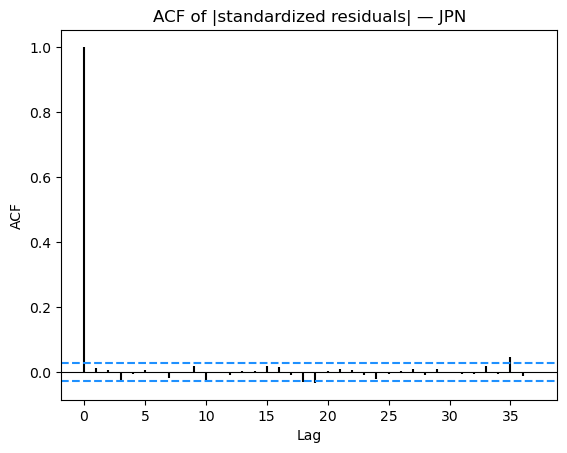

In [7]:
abs_residus = residus.abs()


def acf_plot(x, max_lag=None, ax=None):
    """Sample autocorrelation bar plot with 95% white-noise bounds, mirroring R's acf()."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n_obs = len(x)
    if max_lag is None:
        max_lag = int(10 * np.log10(n_obs))
    x_c = x - x.mean()
    denom = np.sum(x_c**2)
    acf_vals = np.array(
        [1.0] + [np.sum(x_c[lag:] * x_c[:-lag]) / denom for lag in range(1, max_lag + 1)]
    )

    ax = ax or plt.gca()
    ax.vlines(np.arange(max_lag + 1), 0, acf_vals, color="black")
    ax.axhline(0, color="black", linewidth=0.8)
    bound = 1.96 / np.sqrt(n_obs)
    ax.axhline(bound, color="dodgerblue", linestyle="--")
    ax.axhline(-bound, color="dodgerblue", linestyle="--")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    return acf_vals


# R's abs.residus[,10] is the 10th (1-indexed) column -> Python column index 9
acf_plot(abs_residus.iloc[:, 9])
plt.title(f"ACF of |standardized residuals| — {abs_residus.columns[9]}")
plt.show()


In [8]:
data = abs_residus
data.shape


(5051, 22)

#### Define a GPDFlow

In [9]:
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/GPDFlow/Data_and_Model/"



#### Find a suitable threshold for the simulated data

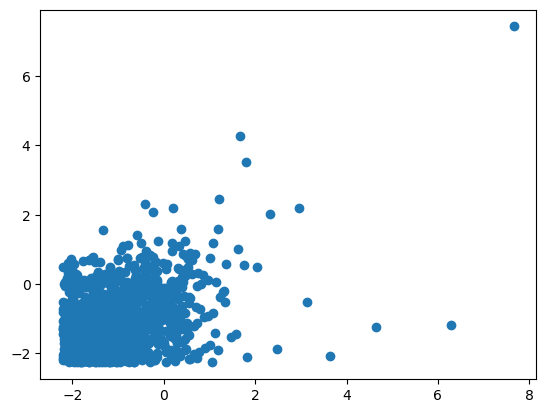

In [10]:
samples_origin = abs_residus.values[:,:]

thres = np.quantile(samples_origin, 0.97,axis=0)

cond = np.any(samples_origin > thres, axis=1)
samples = samples_origin[cond,:]

thres = thres.reshape(1,-1)
samples = samples - thres

plt.scatter(samples[:,0],samples[:,1] )


In [10]:
samples.shape

(1288, 22)

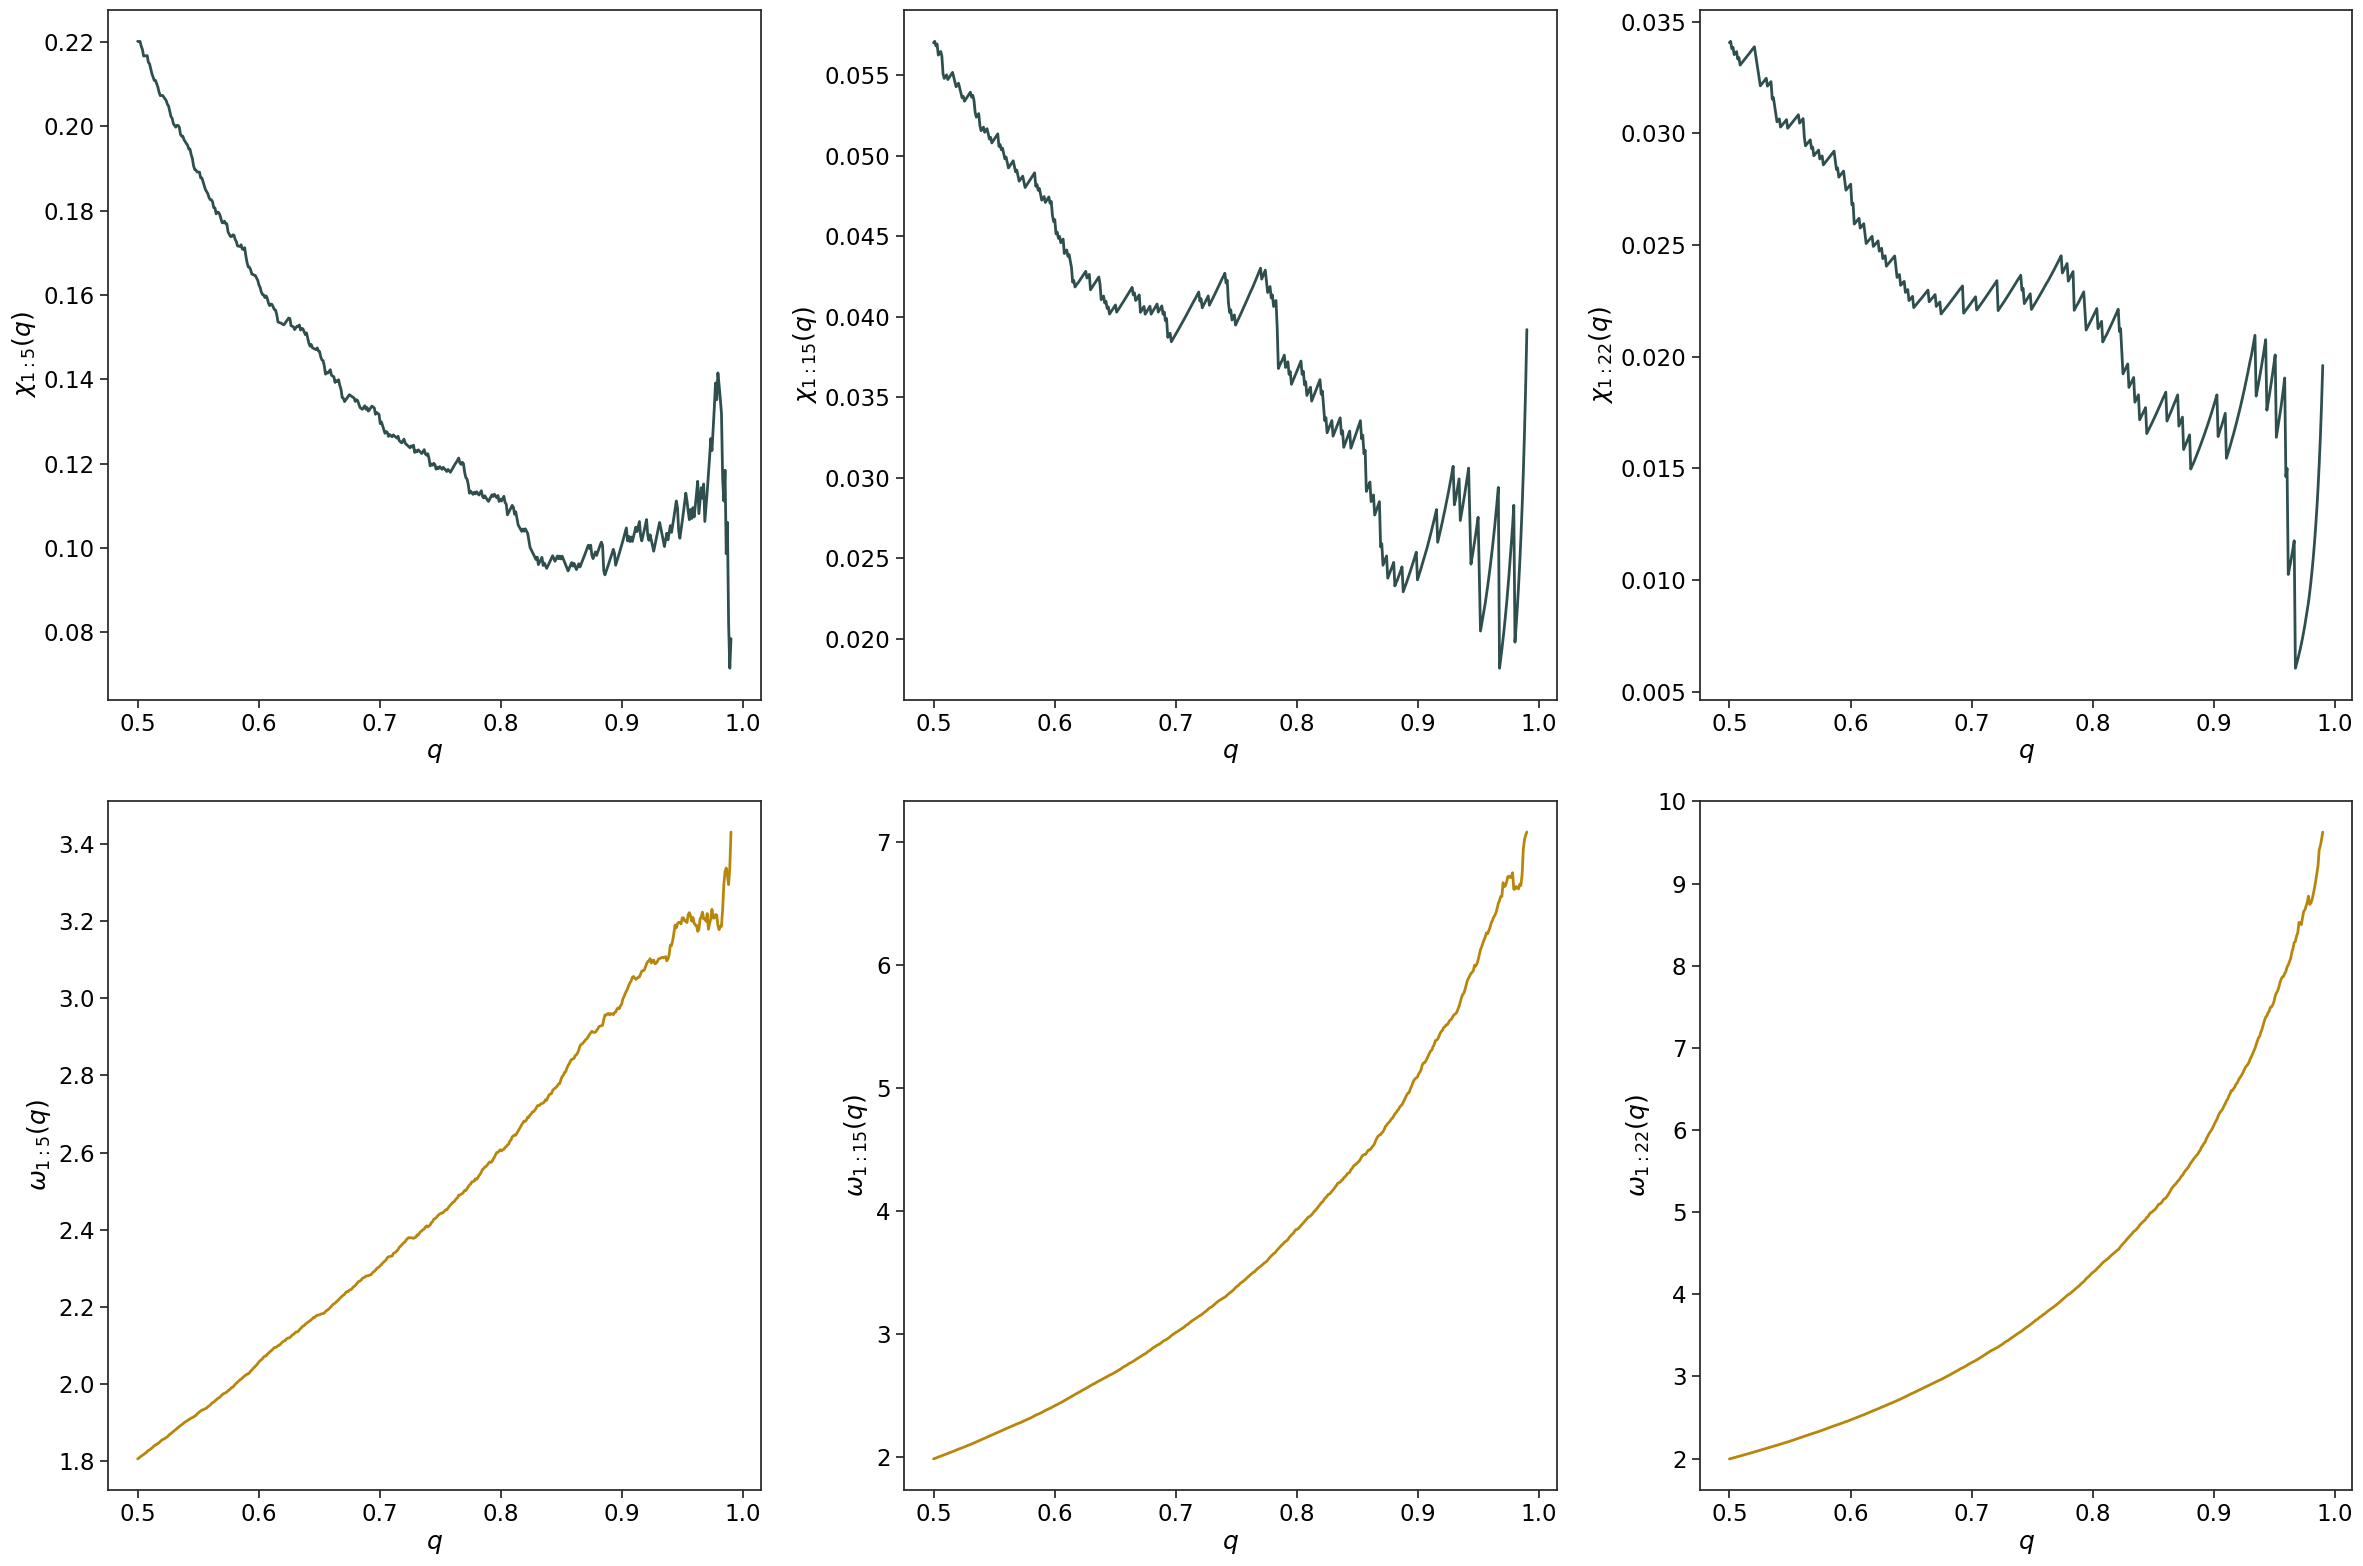

In [11]:
probs = np.linspace(0.5, 0.99, 500)
col_counts = [5, 15, 22]  # CHANGED: was 25 -- 22 columns after removing pegged currencies

chi_emp = {
    k: [empirical_tail_dependence_measure(samples_origin[:, :k], p, 'and') for p in probs]
    for k in col_counts
}
omega_emp = {
    k: [empirical_tail_dependence_measure(samples_origin[:, :k], p, 'or') for p in probs]
    for k in col_counts
}

# 2x3 grid: chi(q) on row 1, omega(q) on row 2, one column per subset size
sns.set(style="ticks", font_scale=1.5)
color_chi = 'darkslategray'
color_omega = 'darkgoldenrod'

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for col, k in enumerate(col_counts):
    ax = axes[0, col]
    ax.plot(probs, chi_emp[k], color=color_chi, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\chi_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

    ax = axes[1, col]
    ax.plot(probs, omega_emp[k], color=color_omega, linewidth=2)
    ax.set_xlabel(r'$q$', color='black')
    ax.set_ylabel(rf'$\omega_{{1:{k}}}(q)$', color='black')
    ax.tick_params(axis='both', labelcolor='black')

fig.tight_layout()
plt.savefig(dir_out + 'Plots/'+'threshold_selection.pdf',bbox_inches='tight')
plt.show()

In [11]:
seed = 1234
rng = np.random.default_rng(seed)  # set seed for reproducibility (change/remove if you want)
idx = rng.permutation(len(samples))

split = int(0.8 * len(samples))
train_idx, val_idx = idx[:split], idx[split:]

train_samples = samples[train_idx]
val_samples   = samples[val_idx]

In [12]:
train_samples.shape

(1030, 22)

# Joint fit with MMD based approach

In [40]:
# --- Model & flow architecture (S representation) ---
dim = samples.shape[1]
latent_size = dim - 1   # S flow lives on R^{d-1}
embed_dim = 3*latent_size
base_s = nf.distributions.DiagGaussian(latent_size)
latent_size_factor = 3
num_layers = 4
torch.manual_seed(0)

b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []

for i in range(num_layers):
    mask = b if i % 2 == 0 else (1 - b)
    s_net = nf.nets.MLP([latent_size + embed_dim, latent_size_factor * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    t_net = nf.nets.MLP([latent_size + embed_dim, latent_size_factor * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    flows.append(ConditionalMaskedAffineFlow(mask, s_net, t_net))
    flows.append(ActNormConditional(latent_size))

flow_model = ConditionalNormalizingFlow(
    d=dim, embed_dim=embed_dim, flows=flows, base=base_s
).to(device)

batch_size = 400
epochs = 500

fix_margin = False

# NOTE (MMD joint fit).  Under use_likelihood=False the only term that carries
# a gradient into (sigma, gamma) is the MMD loss, and MMD on the soft-censored
# standardized values is almost flat w.r.t. the margins -- it does NOT identify
# them.  With penalty_lambda=0 and marg_lambda=0 (as in the likelihood cell this
# was copied from) the optimizer is therefore free to walk sigma/gamma into a
# region where every row has some component with sigma_j + gamma_j x_ij <= 0.
# Once that happens `valid` is all-False, `mmd_censored_loss` is never called,
# and `total_loss` silently collapses to exactly 0 -- the "val loss suddenly
# drops to 0" symptom.  So the margins MUST be anchored here:
#   * penalty_lambda = 1e4  -> quadratic barrier keeping sigma_j + gamma_j x_ij > 0
#   * marg_lambda    = 300  -> conditional-marginal GPD NLL pins (sigma, gamma)
#                              near the per-margin MLE (same value as LIK_CFG)
model = S_mGPD_NF(
    dim=dim,
    flow=flow_model,
    device=device,
    penalty_lambda=1e4,
    fix_margin=False,
    marg_lambda=10,
    use_likelihood=False,
    mmd_lambda=25,
    mmd_samples_per_face=128,
    mmd_censor_c=0,
    mmd_censor_tau=0.15,
    mmd_indicator_alpha=10,
    mmd_indicator_rho=5,
)

# --- Optionally initialize marginal (sigma, gamma) parameters from
# univariate GPD fits on the marginal exceedances, instead of the default
# sigma=1, gamma=0 -- gives the joint optimizer a warm start closer to the
# per-margin MLE before it starts trading off against the flow/dependence terms. ---
init_margins_from_uni_gpd = True

if init_margins_from_uni_gpd and not fix_margin:
    print('Fitting univariate GPD margins to initialize sigma, gamma...')
    init_sigmas = []
    init_gammas = []
    for i in range(dim):
        data_i = train_samples[train_samples[:, i] > 0, i]
        c, loc, scale = stats.genpareto.fit(data_i, floc=0)
        init_gammas.append(c)
        init_sigmas.append(scale)
    init_sigmas = np.array(init_sigmas)
    # clip away from +/-1 so the inverse of gamma = tanh(theta) stays finite
    init_gammas = np.clip(np.array(init_gammas), -0.999, 0.999)

    with torch.no_grad():
        model.data_transform.log_sigma.copy_(
            torch.tensor(np.log(init_sigmas), dtype=torch.float32, device=device)
        )
        model.data_transform.theta.copy_(
            torch.tensor(np.arctanh(init_gammas), dtype=torch.float32, device=device)
        )

    print(f'Scipy Estimated Gammas: {init_gammas.round(3)}')
    print(f'Scipy Estimated Sigmas: {init_sigmas.round(3)}')

optimizer = torch.optim.Adam(
    [
        {'params': model.flow_model.parameters(), 'lr': 1e-3},
        {'params': model.data_transform.log_sigma, 'lr': 1e-2},
        {'params': model.data_transform.theta, 'lr': 1e-2},
        {'params': [model.log_pi_raw], 'lr': 1e-3},
    ],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

print('Initial Sigma:', model.get_sigma().detach().cpu().numpy())
print('Initial Gamma:', model.get_gamma().detach().cpu().numpy())

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Make tensors
train_data = torch.tensor(np.asarray(train_samples), dtype=torch.float32, device=device)
val_data = torch.tensor(np.asarray(val_samples), dtype=torch.float32, device=device)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, drop_last=False)

# ---- Early stopping config ----
# Selection is on the validation TOTAL loss, NOT val_nll: with
# use_likelihood=False the model hard-codes nll = 0 every epoch, so the old
# `improved = (best_val - val_nll) > min_delta` rule locked best_val to 0 at
# epoch 1 and never updated again (early-stopping at epoch 1+patience with the
# untrained epoch-1 weights).  A warm-up keeps a spuriously low early epoch
# from being checkpointed.  Mirrors the Stage-2 MMD cell.
patience = 100
warmup_epochs = 50
min_delta = 1e-3
best_val = float('inf')
best_state = None
best_epoch = 0
bad_epochs = 0

train_loss_history = []
val_loss_history = []
loss_history = []

torch.autograd.set_detect_anomaly(True)

# --- Stats tracking helpers (mmd_loss / mmd_loss_weighted included so the
# dependence term is actually visible in the log). ---
def init_epoch_stats():
    return {
        'nll': 0.0,
        'support_loss': 0.0,
        'support_loss_weighted': 0.0,
        'marg_loss': 0.0,
        'marg_loss_weighted': 0.0,
        'mmd_loss': 0.0,
        'mmd_loss_weighted': 0.0,
        'total_loss': 0.0,
        'count': 0,
    }

def update_epoch_stats(stats_dict, comps, bsz):
    for key in [
        'nll', 'support_loss', 'support_loss_weighted',
        'marg_loss', 'marg_loss_weighted',
        'mmd_loss', 'mmd_loss_weighted',
        'total_loss',
    ]:
        stats_dict[key] += comps[key].item() * bsz
    stats_dict['count'] += bsz

def finalize_epoch_stats(stats_dict):
    if stats_dict['count'] == 0:
        return stats_dict
    return {k: (v if k == 'count' else v / stats_dict['count']) for k, v in stats_dict.items()}


for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_stats = init_epoch_stats()

    for x_data in train_loader:
        # x_data_aux=train_data: the conditional-marginal GPD term is evaluated
        # on the full training sample, not the mini-batch, so the margin anchor
        # is stable across steps (matches the Stage-2 MMD cell / cv_utils).
        comps = model(x_data, return_components=True, x_data_aux=train_data)
        batch_loss = comps['total_loss']

        if torch.isnan(batch_loss) or torch.isinf(batch_loss):
            print(f'[Epoch {epoch}] NaN/Inf detected in TRAIN loss. Stopping.')
            bad_epochs = patience
            break

        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        update_epoch_stats(train_stats, comps, x_data.shape[0])
        loss_history.append(batch_loss.item())

    train_stats = finalize_epoch_stats(train_stats)
    train_epoch_loss = train_stats['total_loss'] if train_stats['count'] > 0 else float('inf')
    train_loss_history.append(train_epoch_loss)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_stats = init_epoch_stats()

    with torch.no_grad():
        for x_val in val_loader:
            comps = model(x_val, return_components=True)
            val_loss = comps['total_loss']

            if torch.isnan(val_loss) or torch.isinf(val_loss):
                print(f'[Epoch {epoch}] NaN/Inf detected in VAL loss. Stopping.')
                bad_epochs = patience
                break

            update_epoch_stats(val_stats, comps, x_val.shape[0])

    val_stats = finalize_epoch_stats(val_stats)
    val_epoch_loss = val_stats['total_loss'] if val_stats['count'] > 0 else float('inf')
    val_loss_history.append(val_epoch_loss)

    scheduler.step()

    # ---------------- LOGGING ----------------
    lr_now = scheduler.get_last_lr()[0]
    print(
        f"Epoch {epoch+1:4d}/{epochs} | "
        f"train={train_stats['total_loss']:.4f} | "
        f"val={val_stats['total_loss']:.4f} | "
        f"lr={lr_now:.3e}"
    )
    print(
        f"  TRAIN | mmd_w={train_stats['mmd_loss_weighted']:.4f} | "
        f"supp_w={train_stats['support_loss_weighted']:.4f} | "
        f"marg_w={train_stats['marg_loss_weighted']:.4f}"
    )
    print(
        f"  VALID | mmd_w={val_stats['mmd_loss_weighted']:.4f} | "
        f"supp_w={val_stats['support_loss_weighted']:.4f} | "
        f"marg_w={val_stats['marg_loss_weighted']:.4f}"
    )

    # ---------------- EARLY STOPPING (on validation TOTAL loss) ----------------
    # Guard: an epoch whose validation MMD term collapsed to 0 (no `valid` row,
    # i.e. the margins pushed every point out of support) is degenerate, not a
    # good fit -- never let it be checkpointed.
    mmd_ok = val_stats['mmd_loss'] > 0.0
    past_warmup = (epoch + 1) > warmup_epochs

    if past_warmup and mmd_ok and best_val == float('inf'):
        improved = True
    else:
        improved = past_warmup and mmd_ok and ((best_val - val_epoch_loss) > min_delta)

    if improved:
        best_val = val_epoch_loss
        best_epoch = epoch + 1
        bad_epochs = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    elif past_warmup:
        bad_epochs += 1

    if bad_epochs >= patience:
        print(f'Early stopping at epoch {epoch + 1} (no val loss improvement for {patience} epochs).')
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f'Optimal epoch (best validation total loss): {best_epoch}')
print('Final Gamma:', model.data_transform.get_gamma())
print('Final Sigma:', model.data_transform.get_sigma())


Fitting univariate GPD margins to initialize sigma, gamma...
Scipy Estimated Gammas: [ 0.181  0.168  0.011 -0.162  0.006 -0.016 -0.073  0.034 -0.059  0.208
  0.01   0.054  0.048  0.078 -0.002  0.284  0.046 -0.202  0.369  0.012
  0.198  0.325]
Scipy Estimated Sigmas: [0.513 0.457 0.52  0.743 0.568 0.565 0.564 0.537 0.666 0.502 0.553 0.557
 0.489 0.528 0.573 0.369 0.42  0.715 0.492 0.574 0.511 0.588]
Initial Sigma: [0.5131791  0.45699814 0.5201476  0.7426999  0.5678604  0.565491
 0.56420517 0.5373536  0.6662766  0.50198066 0.5528155  0.5567657
 0.48861283 0.5277461  0.57291514 0.36866453 0.4196208  0.71545535
 0.49209476 0.5743985  0.51098245 0.58750266]
Initial Gamma: [ 0.18121368  0.16803275  0.01096536 -0.16150422  0.00569971 -0.01643954
 -0.07279948  0.03438777 -0.05931399  0.20766762  0.01006606  0.05416158
  0.04840263  0.07782718 -0.00180745  0.28390226  0.0462085  -0.20200218
  0.36909157  0.01160098  0.1979489   0.32486776]
Epoch    1/500 | train=22.3207 | val=43.8529 | lr=1.000

Epoch    2/500 | train=17.8940 | val=47.0255 | lr=1.000e-03
  TRAIN | mmd_w=13.3703 | supp_w=0.0000 | marg_w=4.5237
  VALID | mmd_w=12.0092 | supp_w=27.5616 | marg_w=7.4546
Epoch    3/500 | train=14.2939 | val=42.8072 | lr=9.999e-04
  TRAIN | mmd_w=9.7563 | supp_w=0.0000 | marg_w=4.5376
  VALID | mmd_w=7.1319 | supp_w=28.2831 | marg_w=7.3921
Epoch    4/500 | train=9.7263 | val=33.1491 | lr=9.998e-04
  TRAIN | mmd_w=5.1664 | supp_w=0.0000 | marg_w=4.5599
  VALID | mmd_w=3.1776 | supp_w=22.6798 | marg_w=7.2916
Epoch    5/500 | train=8.4925 | val=26.1332 | lr=9.998e-04
  TRAIN | mmd_w=3.8991 | supp_w=0.0000 | marg_w=4.5934
  VALID | mmd_w=1.5377 | supp_w=17.0843 | marg_w=7.5113
Epoch    6/500 | train=7.4120 | val=20.9894 | lr=9.996e-04
  TRAIN | mmd_w=2.7746 | supp_w=0.0000 | marg_w=4.6374
  VALID | mmd_w=0.6664 | supp_w=12.8469 | marg_w=7.4761
Epoch    7/500 | train=8.1513 | val=13.6279 | lr=9.995e-04
  TRAIN | mmd_w=3.4591 | supp_w=0.0000 | marg_w=4.6922
  VALID | mmd_w=0.1982 | supp_w=

RMSE sigma (GPDFlow vs univariate GPD): 0.0996
RMSE gamma (GPDFlow vs univariate GPD): 0.0515


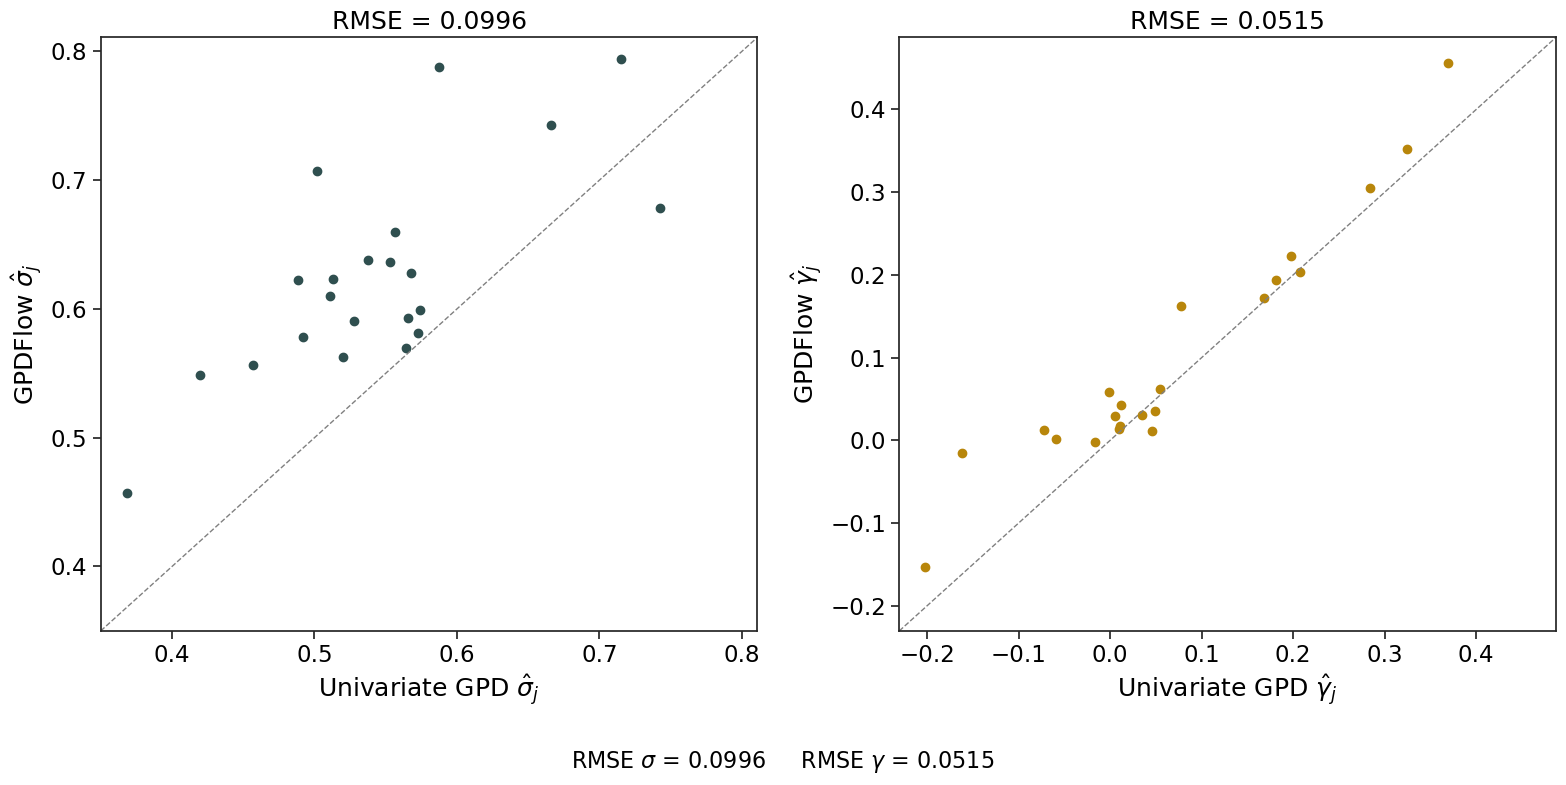

In [41]:
# Fit a univariate GPD to each margin and compare against GPDFlow's estimated sigma, gamma
sigma_hat = model.data_transform.get_sigma().cpu().detach().numpy()
gamma_hat = model.data_transform.get_gamma().cpu().detach().numpy()

uni_sigmas = []
uni_gammas = []
for i in range(dim):
    data_i = train_samples[train_samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    uni_gammas.append(c)
    uni_sigmas.append(scale)
uni_sigmas = np.array(uni_sigmas)
uni_gammas = np.array(uni_gammas)

# RMSE between GPDFlow and univariate GPD marginal estimates
rmse_sigma = np.sqrt(np.mean((sigma_hat - uni_sigmas) ** 2))
rmse_gamma = np.sqrt(np.mean((gamma_hat - uni_gammas) ** 2))
print(f'RMSE sigma (GPDFlow vs univariate GPD): {rmse_sigma:.4f}')
print(f'RMSE gamma (GPDFlow vs univariate GPD): {rmse_gamma:.4f}')

sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

ax = axes[0]
ax.scatter(uni_sigmas, sigma_hat, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\sigma}_j$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\sigma}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')
ax.set_title(f'RMSE = {rmse_sigma:.4f}', color='black')

ax = axes[1]
ax.scatter(uni_gammas, gamma_hat, color='darkgoldenrod')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Univariate GPD $\hat{\gamma}_j$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\gamma}_j$', color='black')
ax.tick_params(axis='both', labelcolor='black')
ax.set_title(f'RMSE = {rmse_gamma:.4f}', color='black')

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.01,
         rf'RMSE $\sigma$ = {rmse_sigma:.4f}     RMSE $\gamma$ = {rmse_gamma:.4f}',
         ha='center', va='bottom', color='black', fontsize=16)
plt.show()

In [42]:

chi_true = cf.pairwise_chi_from_data(samples_origin,p=0.97)
model.eval()

samples_obs, samples_std, samples_s = model.sample(30000)
samples_simu = samples_obs.cpu().detach()
chi_hat = cf.pairwise_chi_from_data(samples_simu,p=0.90)
print(cf.tde_chi(chi_hat, chi_true))

0.08804812614078132


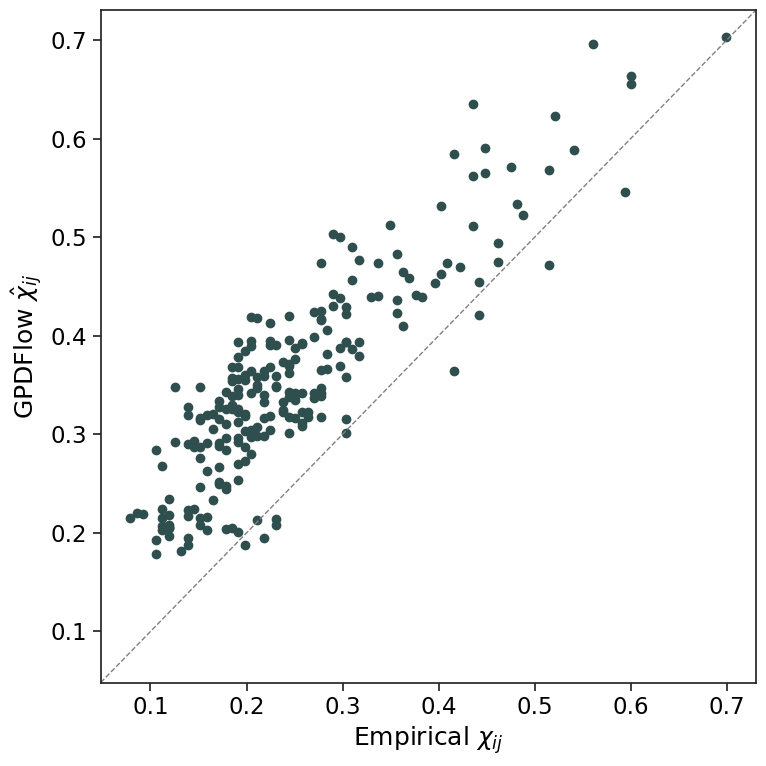

In [39]:
# Scatter plot of empirical vs. GPDFlow-estimated pairwise chi, over the upper
# triangular block (all i<j pairs)
idx = np.triu_indices(dim, k=1)
chi_true_upper = chi_true[idx]
chi_hat_upper = chi_hat[idx]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_upper, chi_hat_upper, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()


fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_chi_likeli.pdf',bbox_inches='tight')
plt.show()

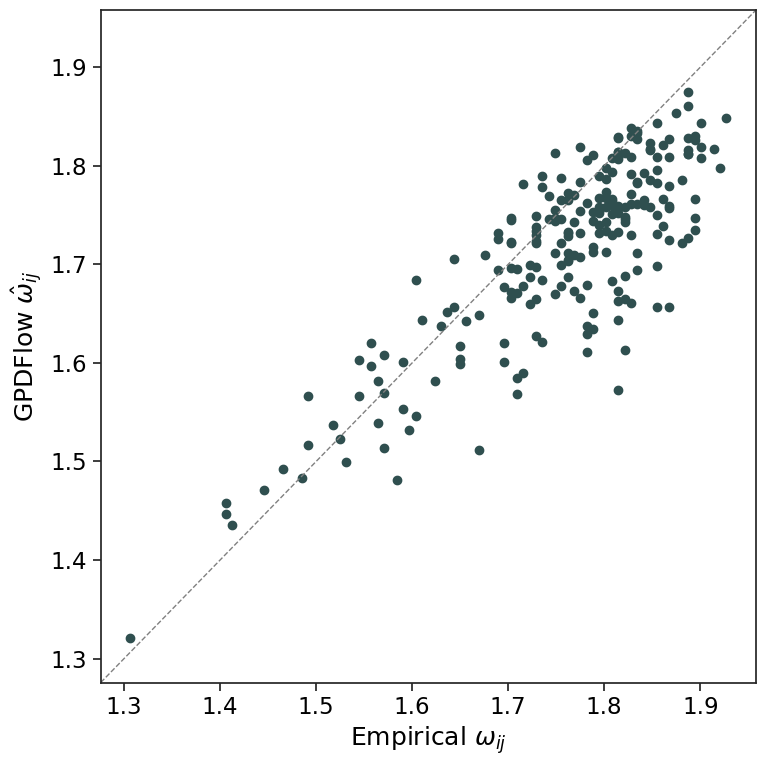

In [70]:
# Pairwise omega (extremal dependence via P(U_i>p or U_j>p)) for empirical vs. GPDFlow
omega_true = cf.pairwise_omega_from_data(samples_origin, p=0.97)
omega_hat = cf.pairwise_omega_from_data(samples_simu, p=0.90)

# Scatter plot of empirical vs. GPDFlow-estimated pairwise omega, over the upper
# triangular block (all i<j pairs)
idx = np.triu_indices(dim, k=1)
omega_true_upper = omega_true[idx]
omega_hat_upper = omega_hat[idx]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(omega_true_upper, omega_hat_upper, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\omega_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\omega}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()

fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_omega_likeli.pdf',bbox_inches='tight')
plt.show()


### Simultaneous exceedance probability: empirical vs. GPDFlow (likelihood-based)

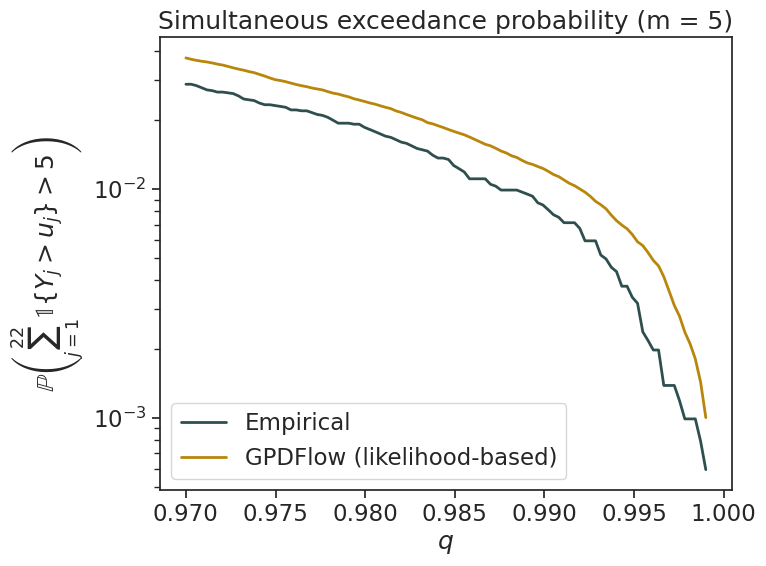

In [71]:
# Simultaneous exceedance probability for the likelihood-based GPDFlow fit.
# samples_simu lives in `samples`' shifted coordinates (samples_origin - thres,
# conditional on at least one margin exceeding thres), so it is rescaled back to
# samples_origin's raw scale before use. The model only represents the
# conditional exceedance-cluster distribution, so its unconditional probability
# is recovered via the standard POT/mGPD decomposition
#   P(sum_j 1{Y_j>u_j} > m) = P(cluster) * P(sum_j 1{Y_j>u_j} > m | cluster)
# (CLAUDE.md Sec 2.4: Monte Carlo inference for joint exceedance probabilities).
p_cluster = samples.shape[0] / samples_origin.shape[0]
samples_simu_raw = samples_simu.numpy() + thres

m_fixed = 5
q_grid = np.linspace(0.97, 0.999, 100)

emp_probs = [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed) for q in q_grid]
model_probs = [
    p_cluster * cf.simultaneous_exceedance_probability(samples_simu_raw, q, m_fixed, X_ref=samples_origin)
    for q in q_grid
]

plt.figure(figsize=(8, 6))
plt.plot(q_grid, emp_probs, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(q_grid, model_probs, color='darkgoldenrod', linewidth=2, label='GPDFlow (likelihood-based)')
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim}}} \mathbb{{1}}\{{Y_j > u_j\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

# Two stage training with likelihood based approach

### Stage 1: standardize margins via univariate GPD fit

In [112]:
# --- Stage 1: fit a univariate GPD to each margin of samples_origin, then
# standardize onto the unit-exponential mGPD scale using the fitted sigma, gamma
# (same construction as the "Standardize margins..." section below, kept
# self-contained here under its own `_2s` suffix) ---
thres_2s = np.quantile(samples_origin, 0.97, axis=0)

uni_sigma_2s = []
uni_gamma_2s = []
for j in range(samples_origin.shape[1]):
    excess_j = samples_origin[samples_origin[:, j] > thres_2s[j], j] - thres_2s[j]
    c, loc, scale = stats.genpareto.fit(excess_j, floc=0)
    uni_gamma_2s.append(c)
    uni_sigma_2s.append(scale)
uni_sigma_2s = np.array(uni_sigma_2s)
uni_gamma_2s = np.array(uni_gamma_2s)

# NOTE: use the independent per-margin scipy GPD fits computed above (matching
# MMD_loss_test.ipynb's In[8]); do NOT overwrite with the joint-likelihood
# GPDFlow margins sigma_hat / gamma_hat -- that made samples_2s differ from that
# notebook's samples_fm.
print('Stage 1 univariate GPD Gamma:', uni_gamma_2s.round(3))
print('Stage 1 univariate GPD Sigma:', uni_sigma_2s.round(3))

# g_std standardization (CLAUDE.md Sec 3.1), applied margin-by-margin using the
# fitted sigma, gamma:
#   Z_j = (1/gamma_j) * log(1 + gamma_j * (X_j - thres_j) / sigma_j),  gamma_j != 0
#   Z_j = (X_j - thres_j) / sigma_j,                                   gamma_j == 0
shifted_2s = samples_origin - thres_2s.reshape(1, -1)

gamma_zero_2s = np.isclose(uni_gamma_2s, 0.0)
gamma_safe_2s = np.where(gamma_zero_2s, 1.0, uni_gamma_2s)

# g_std of a margin *below* its GPD support boundary (1 + gamma*(x-u)/sigma <= 0)
# is genuinely -inf.  The previous code clipped that GPD argument to 1e-6, which
# mapped every non-exceeding margin to Z_j = log(1e-6)/gamma_j ~ -40..-55 -- a
# spurious discontinuous cliff that then dominates the mGPD generator likelihood
# (every family becomes un-fittable, val-NLL ~65-136 vs ~19-25 on the raw scale,
# and the fit collapses toward a near-comonotone generator -> chi ~doubles).
# Instead evaluate Z honestly and floor it on the standardized (unit-exponential)
# scale: a few units below 0 already means "did not exceed" and carries no
# marginal-tail information, so it must not drive the shift integral.
# Z_FLOOR = -6.0
inside_2s = 1.0 + gamma_safe_2s * shifted_2s / uni_sigma_2s
inside_ok_2s = inside_2s > 0

samples_origin_std_2s = np.where(
    gamma_zero_2s,
    shifted_2s / uni_sigma_2s,
    np.log(np.where(inside_ok_2s, inside_2s, 1.0)) / gamma_safe_2s,
)
samples_origin_std_2s = np.where((~gamma_zero_2s) & ~inside_ok_2s, -np.inf,
                                 samples_origin_std_2s)
# samples_origin_std_2s = np.clip(samples_origin_std_2s, Z_FLOOR, None)


Stage 1 univariate GPD Gamma: [0.248 0.251 0.199 0.157 0.17  0.149 0.133 0.11  0.131 0.264 0.139 0.146
 0.222 0.143 0.118 0.336 0.196 0.048 0.353 0.126 0.22  0.356]
Stage 1 univariate GPD Sigma: [0.521 0.439 0.448 0.587 0.497 0.503 0.51  0.524 0.557 0.52  0.51  0.539
 0.447 0.527 0.546 0.371 0.385 0.587 0.498 0.515 0.518 0.585]


In [113]:
# Re-threshold the standardized data at its own 0.97 quantile to obtain the joint
# threshold-exceedance data on the standardized scale (mirrors the `samples`
# construction in the Joint fit section above), then split train/val the same
# way (80/20, seed 1234).
thres_std_2s = 0
cond_2s = np.any(samples_origin_std_2s > thres_std_2s, axis=1)
samples_2s = samples_origin_std_2s[cond_2s, :] - thres_std_2s

seed = 1234
rng = np.random.default_rng(seed)
idx_2s = rng.permutation(len(samples_2s))

split_2s = int(0.8 * len(samples_2s))
train_idx_2s, val_idx_2s = idx_2s[:split_2s], idx_2s[split_2s:]

train_samples_2s = samples_2s[train_idx_2s]
val_samples_2s = samples_2s[val_idx_2s]

# sanity check: non-exceeding margins must land in ~[Z_FLOOR, 0], not at ~-55
print('samples_2s min non-exceeding entry:',
      float(samples_2s[samples_2s < 0].min()))
samples_2s.shape, train_samples_2s.shape, val_samples_2s.shape


samples_2s min non-exceeding entry: -inf


((1288, 22), (1030, 22), (258, 22))

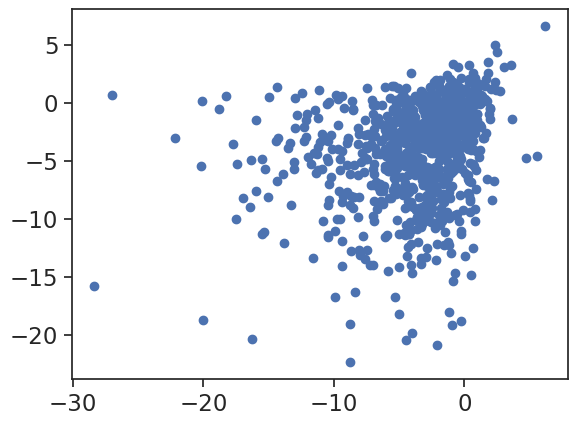

In [114]:
plt.scatter(samples_2s[:,0],samples_2s[:,1] )


### Stage 2: fit GPDFlow with `fix_margin=True`, `use_likelihood=False`

Same architecture and training hyperparameters as the *Joint fit with likelihood based approach* section above, applied to the stage-1 standardized exceedances (`train_samples_2s` / `val_samples_2s`).

> **Note:** the *Stage 1* cell was changed so non-exceeding margins are floored on the standardized scale at `Z_FLOOR` (previously they were clipped to about -55 on the standardized scale, which made every mGPD generator un-fittable). The `model_2s` outputs stored in this section were produced with the old standardization and are **stale until this section is re-run**.


In [ ]:
# --- Stage 2: fit GPDFlow with fix_margin=True, use_likelihood=False (MMD
# based objective) on the stage-1 standardized exceedances -- same
# architecture as the "Joint fit with likelihood based approach" section
# above (dim/latent_size/embed_dim are recomputed here since dim_2s can differ
# from `dim` if the re-thresholding above dropped/added exceedance rows). ---
dim_2s = samples_2s.shape[1]
latent_size_2s = dim_2s - 1
embed_dim_2s = 3 * latent_size_2s
base_s_2s = nf.distributions.DiagGaussian(latent_size_2s)
latent_size_factor_2s = 2
num_layers_2s = 4
torch.manual_seed(0)

b_2s = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size_2s)])
flows_2s = []

for i in range(num_layers_2s):
    mask = b_2s if i % 2 == 0 else (1 - b_2s)
    s_net = nf.nets.MLP([latent_size_2s + embed_dim_2s, latent_size_factor_2s * latent_size_2s, latent_size_2s], init_zeros=True, output_fn='tanh')
    t_net = nf.nets.MLP([latent_size_2s + embed_dim_2s, latent_size_factor_2s * latent_size_2s, latent_size_2s], init_zeros=True, output_fn='tanh')
    flows_2s.append(ConditionalMaskedAffineFlow(mask, s_net, t_net))
    flows_2s.append(ActNormConditional(latent_size_2s))

flow_model_2s = ConditionalNormalizingFlow(
    d=dim_2s, embed_dim=embed_dim_2s, flows=flows_2s, base=base_s_2s
).to(device)

batch_size_2s = 400
epochs_2s = 500

model_2s = S_mGPD_NF(
    dim=dim_2s,
    flow=flow_model_2s,
    device=device,
    penalty_lambda=1e4,
    fix_margin=True,
    marg_lambda=0,
    use_likelihood=False,
    mmd_lambda=25,
    mmd_samples_per_face=128,
    mmd_censor_c=0,
    mmd_censor_tau=0.15,
    mmd_indicator_alpha=10,
    mmd_indicator_rho=5,
)

# fix_margin=True freezes data_transform.log_sigma / theta as plain zero tensors
# (sigma=1, gamma=0), so unlike the Joint fit section's optimizer, this one only
# covers the flow and face weights -- same lr choices as that section for those
# two groups (1e-3 each).
optimizer_2s = torch.optim.Adam(
    [
        {'params': model_2s.flow_model.parameters(), 'lr': 1e-3},
        {'params': [model_2s.log_pi_raw], 'lr': 1e-3},
    ],
)
scheduler_2s = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_2s, epochs_2s)

print('Sigma (fixed):', model_2s.get_sigma().detach().cpu().numpy())
print('Gamma (fixed):', model_2s.get_gamma().detach().cpu().numpy())

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

train_data_2s = torch.tensor(np.asarray(train_samples_2s), dtype=torch.float32, device=device)
val_data_2s = torch.tensor(np.asarray(val_samples_2s), dtype=torch.float32, device=device)

train_loader_2s = DataLoader(train_data_2s, batch_size=batch_size_2s, shuffle=True, drop_last=False)
val_loader_2s = DataLoader(val_data_2s, batch_size=batch_size_2s, shuffle=False, drop_last=False)

# ---- Early stopping config (same as Joint fit section), plus a warm-up
# period before any epoch can be recorded as "best" -- mirrors the MMD-based
# training cell, since under use_likelihood=False the NLL term is always 0
# (never computed) and can't be used to pick the best epoch -- checkpointing
# below is therefore driven by val_epoch_loss (total_loss), not val_nll. ----
patience_2s = 100
warmup_epochs_2s = 50
min_delta_2s = 1e-3
best_val_2s = float('inf')
best_state_2s = None
best_epoch_2s = 0
bad_epochs_2s = 0

train_loss_history_2s = []
val_loss_history_2s = []

torch.autograd.set_detect_anomaly(True)

# --- Stats tracking helpers (redefined locally with mmd_loss tracking,
# unlike the Joint fit section's likelihood-only versions above). ---
def init_epoch_stats():
    return {
        'nll': 0.0,
        'support_loss': 0.0,
        'support_loss_weighted': 0.0,
        'marg_loss': 0.0,
        'marg_loss_weighted': 0.0,
        'mmd_loss': 0.0,
        'mmd_loss_weighted': 0.0,
        'total_loss': 0.0,
        'count': 0,
    }

def update_epoch_stats(stats_dict, comps, bsz):
    for key in [
        'nll', 'support_loss', 'support_loss_weighted',
        'marg_loss', 'marg_loss_weighted',
        'mmd_loss', 'mmd_loss_weighted',
        'total_loss',
    ]:
        stats_dict[key] += comps[key].item() * bsz
    stats_dict['count'] += bsz

def finalize_epoch_stats(stats_dict):
    if stats_dict['count'] == 0:
        return stats_dict
    return {k: (v if k == 'count' else v / stats_dict['count']) for k, v in stats_dict.items()}

for epoch in range(epochs_2s):
    model_2s.train()
    train_stats = init_epoch_stats()

    for x_data in train_loader_2s:
        comps = model_2s(x_data, return_components=True, x_data_aux=train_data_2s)
        batch_loss = comps['total_loss']

        if torch.isnan(batch_loss) or torch.isinf(batch_loss):
            print(f'[Epoch {epoch}] NaN/Inf detected in TRAIN loss. Stopping.')
            bad_epochs_2s = patience_2s
            break

        optimizer_2s.zero_grad(set_to_none=True)
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_2s.parameters(), max_norm=1)
        optimizer_2s.step()

        update_epoch_stats(train_stats, comps, x_data.shape[0])

    train_stats = finalize_epoch_stats(train_stats)
    train_epoch_loss = train_stats['total_loss'] if train_stats['count'] > 0 else float('inf')
    train_loss_history_2s.append(train_epoch_loss)

    model_2s.eval()
    val_stats = init_epoch_stats()

    with torch.no_grad():
        for x_val in val_loader_2s:
            comps = model_2s(x_val, return_components=True)
            val_loss = comps['total_loss']

            if torch.isnan(val_loss) or torch.isinf(val_loss):
                print(f'[Epoch {epoch}] NaN/Inf detected in VAL loss. Stopping.')
                bad_epochs_2s = patience_2s
                break

            update_epoch_stats(val_stats, comps, x_val.shape[0])

    val_stats = finalize_epoch_stats(val_stats)
    val_epoch_loss = val_stats['total_loss'] if val_stats['count'] > 0 else float('inf')
    val_loss_history_2s.append(val_epoch_loss)

    scheduler_2s.step()

    lr_now = scheduler_2s.get_last_lr()[0]
    print(
        f"Epoch {epoch+1:4d}/{epochs_2s} | "
        f"train={train_stats['total_loss']:.4f} | "
        f"val={val_stats['total_loss']:.4f} | "
        f"lr={lr_now:.3e}"
    )
    print(
        f"  TRAIN | mmd_w={train_stats['mmd_loss_weighted']:.4f} | "
        f"supp_w={train_stats['support_loss_weighted']:.4f} | "
        f"marg_w={train_stats['marg_loss_weighted']:.4f}"
    )
    print(
        f"  VALID | mmd_w={val_stats['mmd_loss_weighted']:.4f} | "
        f"supp_w={val_stats['support_loss_weighted']:.4f} | "
        f"marg_w={val_stats['marg_loss_weighted']:.4f}"
    )

    # Only start recording a "best" epoch once past the warmup period, so an
    # early, largely-accidental low val loss can't get checkpointed before the
    # flow has had a chance to actually converge (same guard as the MMD-based
    # training cell). Checkpoint selection is based on val_epoch_loss
    # (total_loss), since val_nll is always 0 under use_likelihood=False.
    past_warmup = (epoch + 1) > warmup_epochs_2s
    if past_warmup and best_val_2s == float('inf'):
        # First post-warmup epoch: nothing to compare against yet, so it
        # always sets the initial baseline.
        improved = True
    else:
        improved = past_warmup and ((best_val_2s - val_epoch_loss) > min_delta_2s)

    if improved:
        best_val_2s = val_epoch_loss
        best_epoch_2s = epoch + 1
        bad_epochs_2s = 0
        best_state_2s = {k: v.detach().cpu().clone() for k, v in model_2s.state_dict().items()}
    elif past_warmup:
        bad_epochs_2s += 1
    # else: still in warmup -- don't count against patience yet.

    if bad_epochs_2s >= patience_2s:
        print(f'Early stopping at epoch {epoch + 1} (no val loss improvement for {patience_2s} epochs).')
        break

if best_state_2s is not None:
    model_2s.load_state_dict(best_state_2s)

print(f'Optimal epoch (best validation loss): {best_epoch_2s}')
print('Final Gamma (should be ~0, fixed):', model_2s.data_transform.get_gamma())
print('Final Sigma (should be ~1, fixed):', model_2s.data_transform.get_sigma())

NameError: name 'samples_2s' is not defined

In [76]:
# --- Evaluate: pairwise chi comparison against the empirical estimate on samples_origin ---
# pairwise_chi_from_data is rank-based, hence invariant to the per-margin monotone
# g_std transform, so it is valid to compare directly against the raw-scale empirical chi.
chi_true_2s = cf.pairwise_chi_from_data(samples_origin, p=0.97)
model_2s.eval()
samples_obs_2s, samples_std_out_2s, samples_s_2s = model_2s.sample(50000)
samples_simu_2s = samples_obs_2s.cpu().detach()
chi_hat_2s = cf.pairwise_chi_from_data(samples_simu_2s, p=0.90)
print(cf.tde_chi(chi_hat_2s, chi_true_2s))


0.021005093957934942


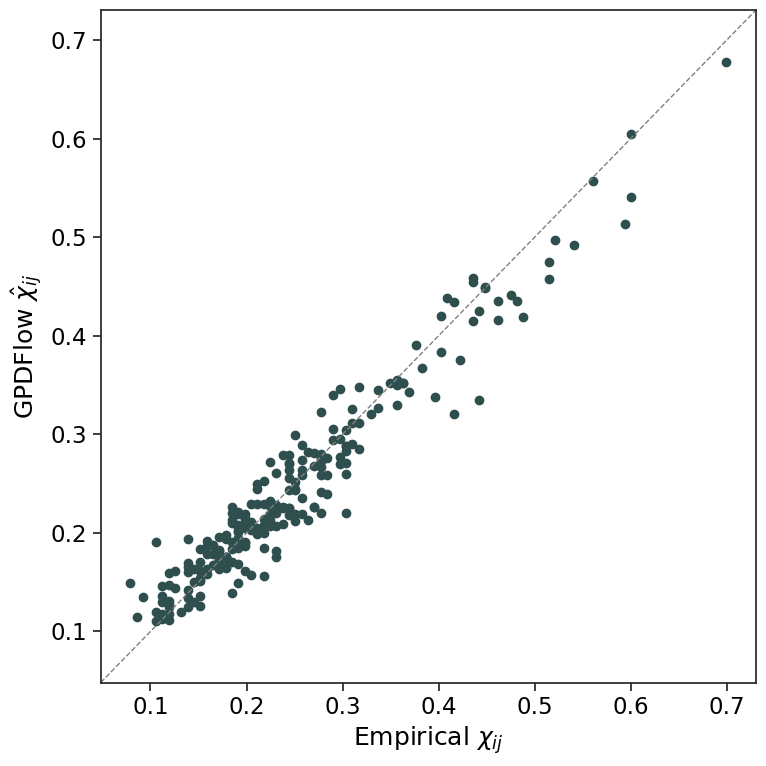

In [77]:
# Scatter plot of empirical vs. GPDFlow-estimated pairwise chi, over the upper
# triangular block (all i<j pairs)
idx_pairs_2s = np.triu_indices(dim_2s, k=1)
chi_true_upper_2s = chi_true_2s[idx_pairs_2s]
chi_hat_upper_2s = chi_hat_2s[idx_pairs_2s]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_upper_2s, chi_hat_upper_2s, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()

fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_chi_MMD.pdf',bbox_inches='tight')
plt.show()



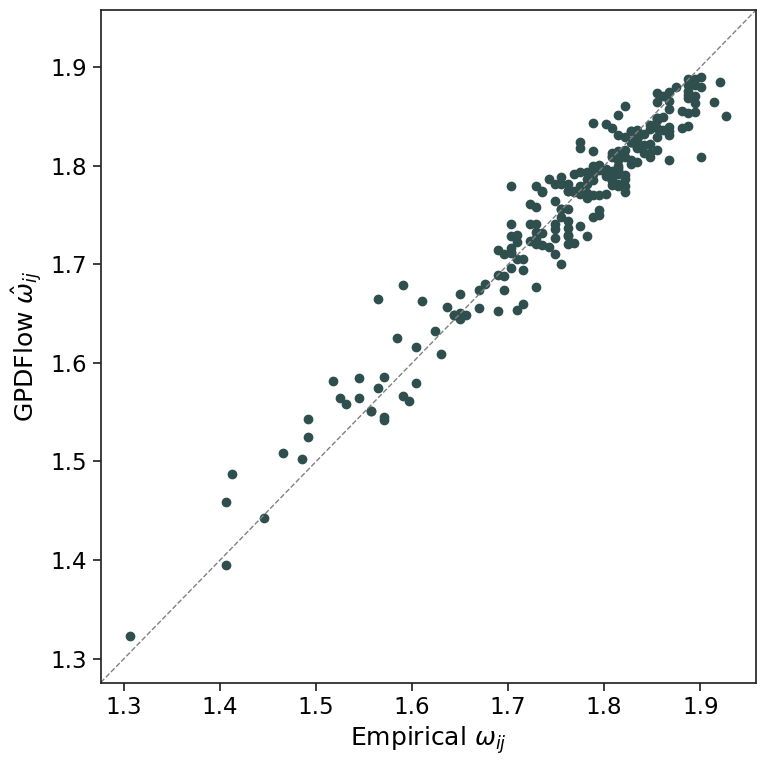

In [78]:
# Pairwise omega (extremal dependence via P(U_i>p or U_j>p)) for the MMD-based fit
omega_true_fm = cf.pairwise_omega_from_data(samples_origin, p=0.97)
omega_hat_fm = cf.pairwise_omega_from_data(samples_simu_2s, p=0.9)

# Scatter plot of empirical vs. GPDFlow-estimated pairwise omega, over the upper
# triangular block (all i<j pairs)
idx = np.triu_indices(22, k=1)
omega_true_upper = omega_true_fm[idx]
omega_hat_upper = omega_hat_fm[idx]

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(omega_true_upper, omega_hat_upper, color='darkslategray')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\omega_{ij}$', color='black')
ax.set_ylabel(r'GPDFlow $\hat{\omega}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
plt.show()

fig.tight_layout()
fig.savefig(dir_out + 'Plots/'+'pairwise_omega_MMD.pdf',bbox_inches='tight')
plt.show()

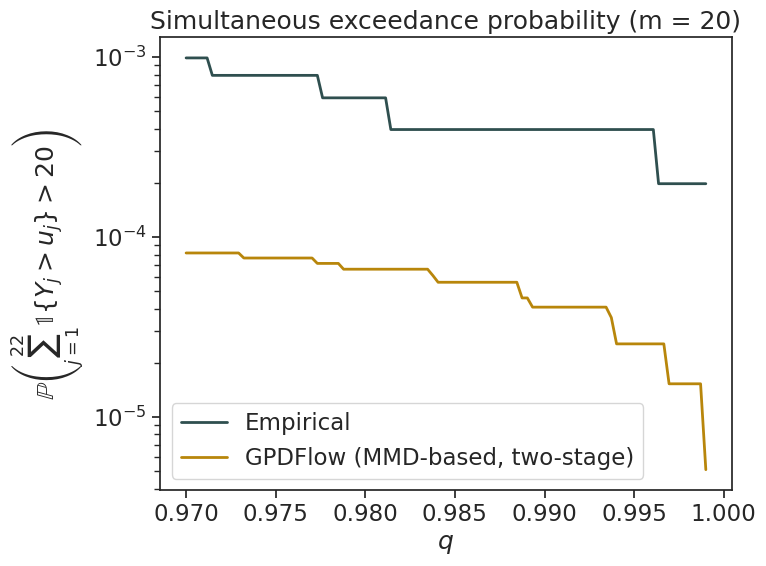

In [79]:
# Simultaneous exceedance probability for the two-stage MMD-based GPDFlow fit
# (model_2s). model_2s is fit with fix_margin=True on the standardized mGPD
# scale (samples_2s = g_std(samples_origin - thres_2s; uni_sigma_2s,
# uni_gamma_2s), CLAUDE.md Sec 3.1), so samples_simu_2s (drawn above) must
# first be mapped back to the observational scale via the inverse
# standardization, using the same stage-1 marginal GPD fit
# (uni_sigma_2s, uni_gamma_2s) and raw threshold thres_2s:
#   X_j = thres_2s_j + sigma_j * (exp(gamma_j * Z_j) - 1) / gamma_j,  gamma_j != 0
#   X_j = thres_2s_j + sigma_j * Z_j,                                  gamma_j == 0
# before it can be compared against samples_origin on the same absolute scale.
samples_simu_2s_np = samples_simu_2s.numpy()
gamma_zero_2s_inv = np.isclose(uni_gamma_2s, 0.0)
gamma_safe_2s_inv = np.where(gamma_zero_2s_inv, 1.0, uni_gamma_2s)
samples_simu_2s_raw = thres_2s + np.where(
    gamma_zero_2s_inv,
    uni_sigma_2s * samples_simu_2s_np,
    uni_sigma_2s * (np.exp(gamma_safe_2s_inv * samples_simu_2s_np) - 1) / gamma_safe_2s_inv,
)

# model_2s only represents the conditional exceedance-cluster distribution, so
# its unconditional probability is recovered via the standard POT/mGPD
# decomposition P(sum_j 1{Y_j>u_j} > m) = P(cluster) * P(... | cluster)
# (CLAUDE.md Sec 2.4), matching the likelihood-based comparison above.
p_cluster_2s = samples_2s.shape[0] / samples_origin.shape[0]

m_fixed = 20
q_grid = np.linspace(0.97, 0.999, 100)

emp_probs = [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed) for q in q_grid]
model_probs_2s = [
    p_cluster_2s * cf.simultaneous_exceedance_probability(samples_simu_2s_raw, q, m_fixed, X_ref=samples_origin)
    for q in q_grid
]

plt.figure(figsize=(8, 6))
plt.plot(q_grid, emp_probs, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(q_grid, model_probs_2s, color='darkgoldenrod', linewidth=2, label='GPDFlow (MMD-based, two-stage)')
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim_2s}}} \mathbb{{1}}\{{Y_j > u_j\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

### Model Comparison

#### Normalizing Flows

**Baseline: probit-copula RealNVP.** A generic deep density estimator to contrast with GPDFlow, fit on the *same* threshold-exceedance slice.

Naively PIT-ing each margin to Uniform(0,1) or unit-Exponential and fitting an affine RealNVP leaves a hard support boundary (the box edge, or 0) exactly where the exceedance data is densest; a Gaussian-base flow has full support on $\mathbb{R}^d$ and leaks mass past that edge. Instead we compose the GPD marginal transform with a probit step, $W_j = \Phi^{-1}(F_j(X_j))$, so every margin lands on the whole real line and the flow only has to learn the *dependence* — matching GPDFlow's design of keeping the flow away from the marginal tails.

Pipeline:
1. Per-margin hybrid CDF $F_j$: empirical body ($x\le 0$) + univariate GPD tail ($x>0$).
2. $W = \Phi^{-1}(F(X))$; fit an unconditional RealNVP on $\mathbb{R}^{22}$ by maximum likelihood. With only ~1k training rows the held-out NLL bottoms within ~15-20 epochs and then diverges while the coupling layers are still learning the tail-asymmetric dependence, so the checkpoint is selected on a held-out *shape* discrepancy (energy distance between a flow sample and the validation set) after a short warm-up, not on held-out NLL.
3. Sample $W^\* \to \Phi \to F^{-1} \to X^\*$; compare pairwise $\chi$/$\omega$ and the simultaneous-exceedance-probability curve against the empirical estimate and the two GPDFlow fits.

**Caveat.** This copula-flow has no asymptotic-dependence or threshold-stability guarantee: its $\chi(q)$ may decay toward 0 and its exceedance curve is unreliable above $q\approx 0.995$ (shaded in the plot). Quantitative error metrics are restricted to the data-supported range.

W_train: finite = True | per-margin mean ~ 0.001 | per-margin std ~ 0.996
W_val  : finite = True


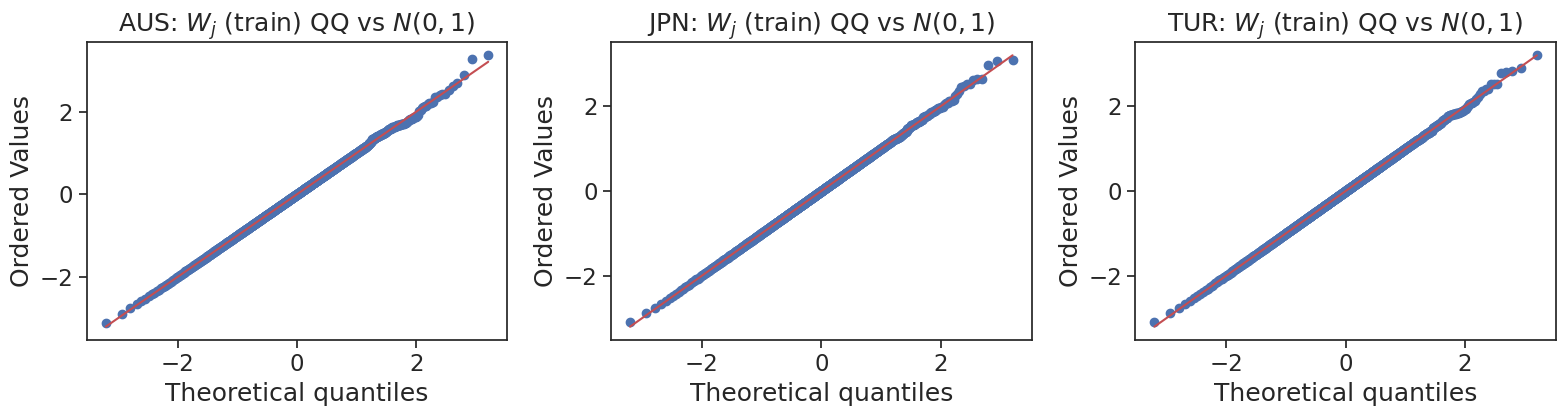

In [80]:
# ============================================================================
# Baseline: probit-copula RealNVP normalizing flow
# ============================================================================
# Trained on the SAME L-shaped POT slice as GPDFlow (`samples` = samples_origin
# sliced at the per-margin 0.97 quantile conditional on at least one margin
# exceeding, shifted so each threshold sits at 0; `train_samples` / `val_samples`
# are the 80/20 split, seed 1234). Margins are handled explicitly by a hybrid
# CDF (empirical body below 0, univariate GPD tail above 0); the flow only models
# the dependence, after a probit transform
#     W_j = Phi^{-1}( F_j(X_j) )
# that maps every margin onto the whole real line -- so the Gaussian-base RealNVP
# is correctly specified and there is no hard lower boundary at 0.
from scipy.stats import genpareto

n_slice = samples.shape[0]

# Per-margin GPD tail fit (scipy genpareto on the positive excesses of the
# training slice) -- same call as the model's marginal init in the Joint-fit cell.
_body_sorted = [np.sort(train_samples[:, j]) for j in range(dim)]
_p0 = np.array([(train_samples[:, j] > 0).mean() for j in range(dim)])
_gpd_sigma = np.empty(dim)
_gpd_gamma = np.empty(dim)
for j in range(dim):
    c, loc, scale = genpareto.fit(train_samples[train_samples[:, j] > 0, j], floc=0)
    _gpd_gamma[j] = c
    _gpd_sigma[j] = scale


def marginal_cdf(x, j):
    """Hybrid CDF F_j: empirical body for x<=0, GPD tail for x>0. Elementwise."""
    x = np.asarray(x, dtype=float)
    n = len(_body_sorted[j])
    body = np.searchsorted(_body_sorted[j], x, side='right') / (n + 1)
    tail = (1.0 - _p0[j]) + _p0[j] * genpareto.cdf(
        np.clip(x, 0.0, None), c=_gpd_gamma[j], scale=_gpd_sigma[j]
    )
    return np.where(x > 0.0, tail, body)


def marginal_ppf(u, j):
    """Hybrid quantile function F_j^{-1}. Elementwise on u in (0, 1)."""
    u = np.asarray(u, dtype=float)
    cut = 1.0 - _p0[j]
    body = np.quantile(_body_sorted[j], np.clip(u, 0.0, 1.0))
    tail_u = np.clip((u - cut) / _p0[j], 0.0, 1.0 - 1e-9)
    tail = genpareto.ppf(tail_u, c=_gpd_gamma[j], scale=_gpd_sigma[j])
    return np.where(u > cut, tail, body)


def to_gaussian(X):
    """X (n x d) in shifted slice coords -> W (n x d) with ~N(0,1) margins."""
    U = np.column_stack([marginal_cdf(X[:, j], j) for j in range(dim)])
    U = np.clip(U, 1.0 / (2 * n_slice), 1.0 - 1.0 / (2 * n_slice))
    return norm.ppf(U)


def from_gaussian(W):
    """W (n x d) with ~N(0,1) margins -> X (n x d) in shifted slice coords."""
    U = norm.cdf(W)
    return np.column_stack([marginal_ppf(U[:, j], j) for j in range(dim)])


W_train = to_gaussian(train_samples)
W_val = to_gaussian(val_samples)
print('W_train: finite =', np.isfinite(W_train).all(),
      '| per-margin mean ~', np.round(W_train.mean(0).mean(), 3),
      '| per-margin std ~', np.round(W_train.std(0).mean(), 3))
print('W_val  : finite =', np.isfinite(W_val).all())

# Probit-data QQ sanity for a few margins
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, j in zip(axes, [0, 9, 21]):
    stats.probplot(W_train[:, j], dist='norm', plot=ax)
    ax.set_title(f'{ctry_codes[j]}: $W_j$ (train) QQ vs $N(0,1)$')
plt.tight_layout()
plt.show()


Epoch    1/400 | train_nll=31.156 | val_nll=30.345 | e_dist=0.0969 | tde_chi(diag)=0.1431
Epoch   10/400 | train_nll=27.651 | val_nll=27.659 | e_dist=0.0454 | tde_chi(diag)=0.1106


Epoch   20/400 | train_nll=26.773 | val_nll=27.255 | e_dist=0.0433 | tde_chi(diag)=0.0980
Epoch   30/400 | train_nll=26.120 | val_nll=26.987 | e_dist=0.0346 | tde_chi(diag)=0.0761
Epoch   40/400 | train_nll=25.619 | val_nll=26.896 | e_dist=0.0319 | tde_chi(diag)=0.0613
Epoch   50/400 | train_nll=25.250 | val_nll=26.928 | e_dist=0.0339 | tde_chi(diag)=0.0487
Epoch   60/400 | train_nll=24.964 | val_nll=26.987 | e_dist=0.0305 | tde_chi(diag)=0.0338
Epoch   70/400 | train_nll=24.729 | val_nll=27.052 | e_dist=0.0302 | tde_chi(diag)=0.0348
Epoch   80/400 | train_nll=24.511 | val_nll=27.280 | e_dist=0.0321 | tde_chi(diag)=0.0299
Epoch   90/400 | train_nll=24.331 | val_nll=27.414 | e_dist=0.0286 | tde_chi(diag)=0.0256
Epoch  100/400 | train_nll=24.130 | val_nll=27.665 | e_dist=0.0315 | tde_chi(diag)=0.0279
Epoch  110/400 | train_nll=24.004 | val_nll=27.938 | e_dist=0.0315 | tde_chi(diag)=0.0252
Epoch  120/400 | train_nll=23.857 | val_nll=28.082 | e_dist=0.0284 | tde_chi(diag)=0.0247
Epoch  130

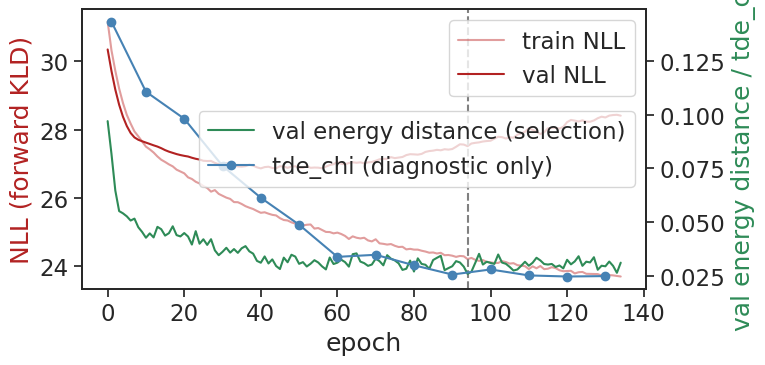

In [81]:
# --- Unconditional RealNVP on R^d (normflows), trained by maximum likelihood ---
# Small (~1k train / 258 val rows), 22-D: a flexible flow overfits the *density* fast
# -- held-out NLL bottoms within ~15-20 epochs and then diverges -- while the
# dependence *shape* (the asymmetric upper-tail contraction that makes a Gaussian-
# scale pair scatter fan out: tight toward the upper-right, wide toward the lower-
# left) is still being built by the coupling layers between roughly epoch 20 and 50.
# Two changes vs a naive fit:
#   1. Select / early-stop on a held-out DISTRIBUTIONAL-SHAPE discrepancy (energy
#      distance between a large flow sample and the validation set) after a short
#      warm-up, NOT on held-out NLL -- which would return a pre-fan checkpoint that
#      has only the global covariance ("direction") and not the fan.
#   2. Keep the flow small (4 coupling layers, hidden 2d) + input jitter, so the
#      selected model is not a pathological density: train/val NLL gap ~3-4 nats
#      here, vs a ~5x val-NLL blow-up for a wider 8-layer / hidden-4d flow.
# This flow is validated as a SAMPLER for the Monte-Carlo risk quantities below, not
# as a calibrated density -- do not use its pointwise log-density. The pairwise-chi
# curve stays a pure diagnostic, never a selection criterion.
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

nf_base = nf.distributions.DiagGaussian(dim)
nf_num_layers = 4          # small flow: 1030 training rows in 22-D
nf_hidden = 2 * dim        # narrow coupling MLPs
sigma_jitter = 0.10
nf_b = torch.tensor([1 if i % 2 == 0 else 0 for i in range(dim)], dtype=torch.float32)
nf_flows = []
for i in range(nf_num_layers):
    s = nf.nets.MLP([dim, nf_hidden, dim], init_zeros=True, output_fn='tanh')  # start at unit scale
    t = nf.nets.MLP([dim, nf_hidden, dim], init_zeros=False)                   # free translation
    mask = nf_b if i % 2 == 0 else (1 - nf_b)
    nf_flows.append(nf.flows.MaskedAffineFlow(mask, t, s))
    nf_flows.append(nf.flows.ActNorm(dim))
flow_baseline = nf.NormalizingFlow(nf_base, nf_flows).to(device)

Wt = torch.tensor(W_train, dtype=torch.float32, device=device)
Wv = torch.tensor(W_val, dtype=torch.float32, device=device)
bl_train_loader = DataLoader(Wt, batch_size=256, shuffle=True, drop_last=False)

bl_epochs = 400
bl_opt = torch.optim.Adam(flow_baseline.parameters(), lr=1e-3, weight_decay=1e-4)
bl_sched = torch.optim.lr_scheduler.CosineAnnealingLR(bl_opt, bl_epochs)

# Selection on held-out energy distance (not NLL). No checkpoint / early-stop
# bookkeeping until after bl_warmup, so the density-overfitting basin near epoch ~15
# (lowest val NLL, but pre-fan) cannot be the one that gets restored.
bl_warmup = 20
bl_patience = 40
bl_sel_samples = 6000
bl_best_score = float('inf')
bl_best_state = None
bl_best_epoch = 0
bl_bad = 0
bl_train_hist, bl_val_hist, bl_edist_hist = [], [], []


def _energy_distance(gen, ref):
    """Energy distance 2 E||G-R|| - E||G-G'|| - E||R-R'|| (lower = closer). Tensors on device."""
    with torch.no_grad():
        d_gr = torch.cdist(gen, ref).mean()
        d_gg = torch.cdist(gen, gen).mean()
        d_rr = torch.cdist(ref, ref).mean()
    return (2.0 * d_gr - d_gg - d_rr).item()


# diagnostic only -- NOT a selection criterion
chi_target = cf.pairwise_chi_from_data(samples_origin, p=0.97)
bl_score_hist = []

for epoch in range(bl_epochs):
    flow_baseline.train()
    running, count = 0.0, 0
    for wb in bl_train_loader:
        bl_opt.zero_grad(set_to_none=True)
        loss = flow_baseline.forward_kld(wb + sigma_jitter * torch.randn_like(wb))
        if torch.isnan(loss) or torch.isinf(loss):
            print(f'[Epoch {epoch}] NaN/Inf in train loss; stopping.')
            bl_bad = bl_patience
            break
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_baseline.parameters(), max_norm=1)
        bl_opt.step()
        running += loss.item() * wb.shape[0]
        count += wb.shape[0]
    bl_sched.step()
    train_nll = running / max(count, 1)

    flow_baseline.eval()
    with torch.no_grad():
        val_nll = flow_baseline.forward_kld(Wv).item()
        W_sel, _ = flow_baseline.sample(bl_sel_samples)
    W_sel = W_sel[torch.isfinite(W_sel).all(dim=1)]
    edist = (
        _energy_distance(W_sel, Wv)
        if W_sel.shape[0] > bl_sel_samples // 4
        else float('inf')
    )
    bl_train_hist.append(train_nll)
    bl_val_hist.append(val_nll)
    bl_edist_hist.append(edist)

    if epoch + 1 > bl_warmup:
        if bl_best_score - edist > 0.0:
            bl_best_score = edist
            bl_best_epoch = epoch + 1
            bl_bad = 0
            bl_best_state = {k: v.detach().cpu().clone() for k, v in flow_baseline.state_dict().items()}
        else:
            bl_bad += 1

    if epoch == 0 or (epoch + 1) % 10 == 0:
        with torch.no_grad():
            W_ev, _ = flow_baseline.sample(20000)
        W_ev = W_ev.cpu().numpy()
        W_ev = W_ev[np.isfinite(W_ev).all(axis=1)]
        score = cf.tde_chi(cf.pairwise_chi_from_data(W_ev, p=0.90), chi_target)
        bl_score_hist.append((epoch + 1, score))
        print(f'Epoch {epoch + 1:4d}/{bl_epochs} | train_nll={train_nll:.3f} | '
              f'val_nll={val_nll:.3f} | e_dist={edist:.4f} | tde_chi(diag)={score:.4f}')

    if epoch + 1 > bl_warmup and bl_bad >= bl_patience:
        print(f'Early stopping at epoch {epoch + 1} (no e-dist improvement for {bl_patience}).')
        break

if bl_best_state is not None:
    flow_baseline.load_state_dict(bl_best_state)
print(f'Baseline flow: best epoch {bl_best_epoch}, val e-dist {bl_best_score:.4f}, '
      f'val NLL there {bl_val_hist[bl_best_epoch - 1]:.4f}')

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(bl_train_hist, color='indianred', alpha=0.6, label='train NLL')
ax1.plot(bl_val_hist, color='firebrick', label='val NLL')
ax1.axvline(bl_best_epoch - 1, color='gray', ls='--')
ax1.set_xlabel('epoch')
ax1.set_ylabel('NLL (forward KLD)', color='firebrick')
ax1.legend(loc='upper right')
ax2 = ax1.twinx()
ax2.plot(bl_edist_hist, color='seagreen', label='val energy distance (selection)')
if bl_score_hist:
    e_s, s_s = zip(*bl_score_hist)
    ax2.plot(e_s, s_s, 'o-', color='steelblue', label='tde_chi (diagnostic only)')
ax2.set_ylabel('val energy distance / tde_chi', color='seagreen')
ax2.legend(loc='center right')
fig.tight_layout()
plt.show()


sampled W* : mean over margins = -0.007 | std over margins = 0.964
corr(train vs sampled Spearman rho, off-diagonal) = 0.991


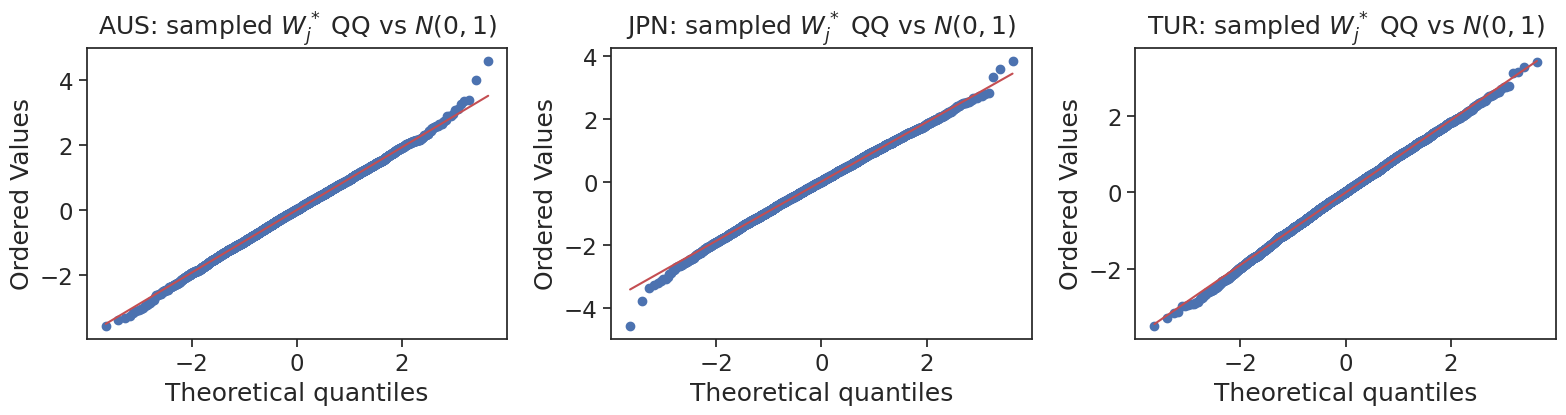

In [82]:
# --- Sanity checks on the fitted baseline flow -----------------------------
from scipy.stats import spearmanr

flow_baseline.eval()
with torch.no_grad():
    W_star, _ = flow_baseline.sample(50000)
W_star = W_star.cpu().numpy()
W_star = W_star[np.isfinite(W_star).all(axis=1)]

print('sampled W* : mean over margins =', W_star.mean(0).mean().round(3),
      '| std over margins =', W_star.std(0).mean().round(3))

# Dependence sanity: rank correlation of sampled vs training pseudo-Gaussian data
rho_tr = spearmanr(W_train).correlation
rho_st = spearmanr(W_star).correlation
iu = np.triu_indices(dim, k=1)
print('corr(train vs sampled Spearman rho, off-diagonal) =',
      np.corrcoef(rho_tr[iu], rho_st[iu])[0, 1].round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, j in zip(axes, [0, 9, 21]):
    stats.probplot(W_star[:5000, j], dist='norm', plot=ax)
    ax.set_title(f'{ctry_codes[j]}: sampled $W^*_j$ QQ vs $N(0,1)$')
plt.tight_layout()
plt.show()


Probit-copula RealNVP   tde_chi   : 0.026788038257964934
Probit-copula RealNVP   tde_omega : 0.025424781114308258


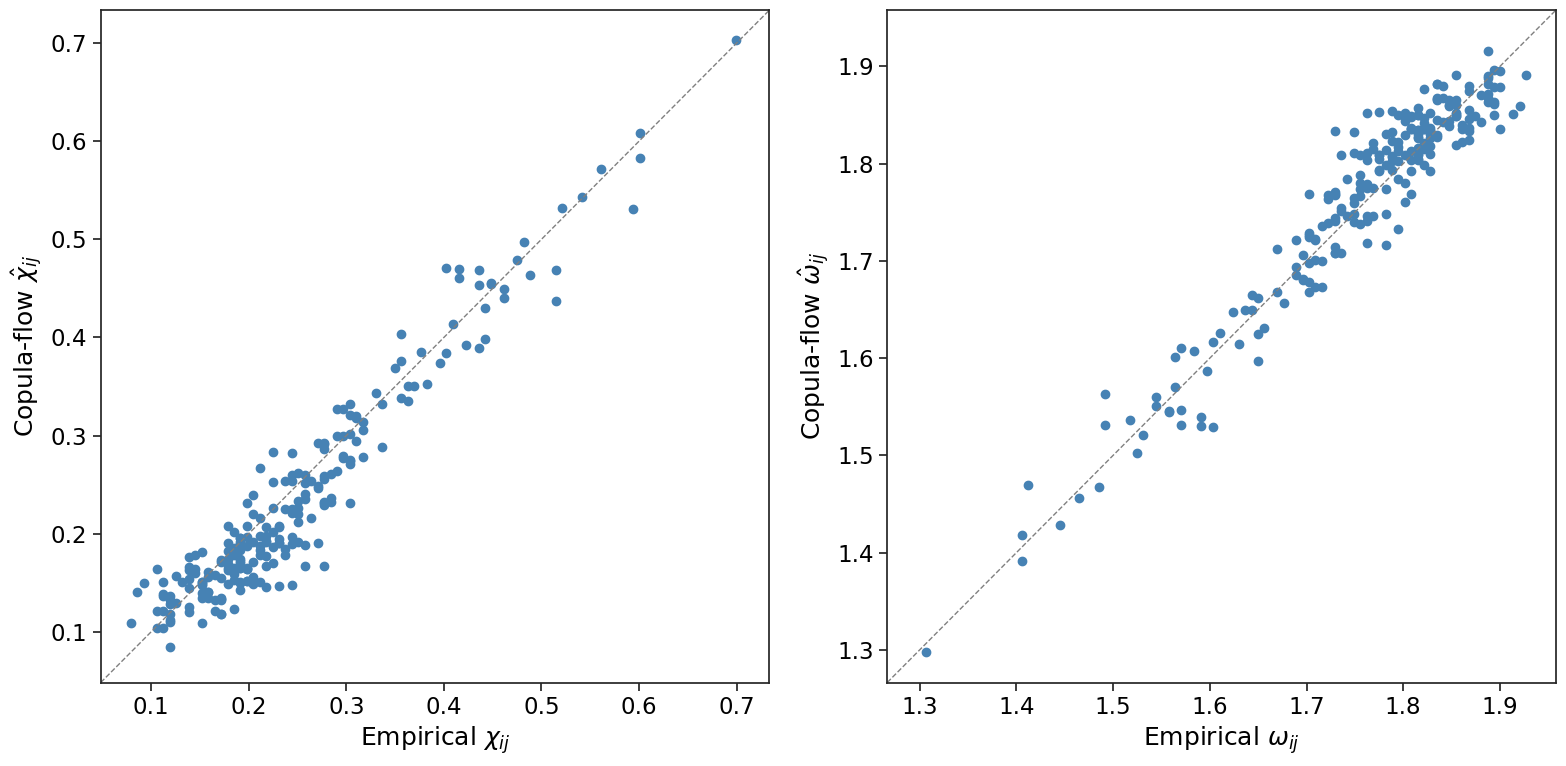

In [83]:
# --- Map baseline-flow samples back to the raw observational scale ----------
X_star = from_gaussian(W_star)              # shifted slice coords
flow_baseline_raw = X_star + thres          # raw scale (samples_origin units)

# Pairwise chi / omega, same conventions as the GPDFlow comparison cells:
# empirical "truth" at p=0.97 on samples_origin; model draws (all in the
# exceedance cluster) evaluated at p=0.90. Both estimators are rank-based, hence
# invariant to the monotone per-margin transforms.
chi_true_bl = cf.pairwise_chi_from_data(samples_origin, p=0.97)
chi_hat_bl = cf.pairwise_chi_from_data(flow_baseline_raw, p=0.90)
omega_true_bl = cf.pairwise_omega_from_data(samples_origin, p=0.97)
omega_hat_bl = cf.pairwise_omega_from_data(flow_baseline_raw, p=0.90)
print('Probit-copula RealNVP   tde_chi   :', cf.tde_chi(chi_hat_bl, chi_true_bl))
print('Probit-copula RealNVP   tde_omega :', cf.tde_chi(omega_hat_bl, omega_true_bl))

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, true_m, hat_m, sym in [
    (axes[0], chi_true_bl, chi_hat_bl, r'\chi'),
    (axes[1], omega_true_bl, omega_hat_bl, r'\omega'),
]:
    ax.scatter(true_m[iu], hat_m[iu], color='steelblue')
    lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
    ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(rf'Empirical ${sym}_{{ij}}$', color='black')
    ax.set_ylabel(rf'Copula-flow $\hat{{{sym}}}_{{ij}}$', color='black')
    ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
# fig.savefig(dir_out + 'Plots/pairwise_chi_omega_flowbaseline.pdf', bbox_inches='tight')
plt.show()


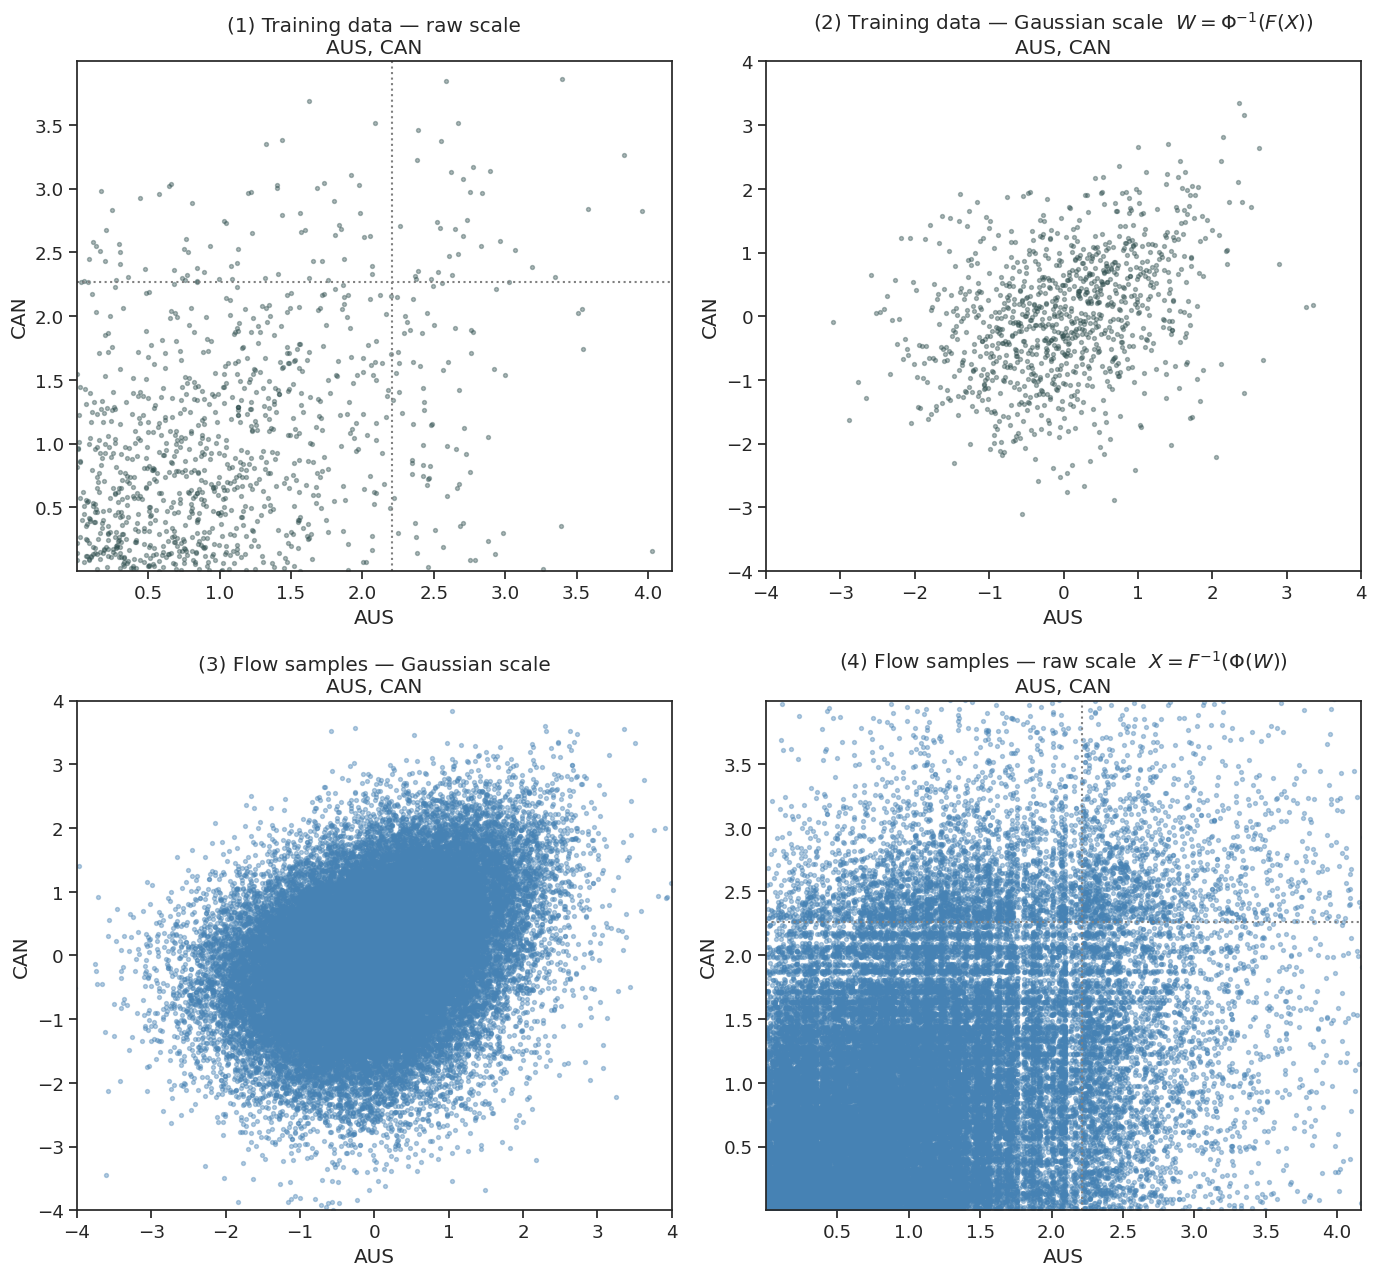

pair: AUS, CAN
  train slice fractions: AUS>u=0.117  CAN>u=0.113  both>u=0.040
  Spearman rho : train(Gaussian) +0.342   flow(Gaussian) +0.329
  Kendall tau  : train           +0.236   flow           +0.223
  chi(0.90)    : train slice     0.359   flow raw       0.321
  chi(0.97)    : full data       0.304


In [84]:
# ---------------------------------------------------------------------------
# Diagnostic: first two margins (AUS, CAN) at every stage of the pipeline.
# If the dependence is lost, this shows *where*.
# ---------------------------------------------------------------------------
c0, c1 = 0, 1
lab = f'{ctry_codes[c0]}, {ctry_codes[c1]}'

train_raw = train_samples[:, [c0, c1]] + thres[0, [c0, c1]]      # (1) raw scale, training slice
Wtr2 = W_train[:, [c0, c1]]                                       # (2) Gaussian scale, training
Wst2 = W_star[:, [c0, c1]]                                        # (3) Gaussian scale, flow samples
gen_raw = flow_baseline_raw[:, [c0, c1]]                          # (4) raw scale, flow samples

sns.set(style="ticks", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(14, 13))

axes[0, 0].scatter(train_raw[:, 0], train_raw[:, 1], s=8, alpha=0.4, color='darkslategray')
axes[0, 0].axvline(thres[0, c0], color='gray', ls=':'); axes[0, 0].axhline(thres[0, c1], color='gray', ls=':')
axes[0, 0].set_title(f'(1) Training data \u2014 raw scale\n{lab}')

axes[0, 1].scatter(Wtr2[:, 0], Wtr2[:, 1], s=8, alpha=0.4, color='darkslategray')
axes[0, 1].set_title(f'(2) Training data \u2014 Gaussian scale  $W=\\Phi^{{-1}}(F(X))$\n{lab}')

axes[1, 0].scatter(Wst2[:, 0], Wst2[:, 1], s=8, alpha=0.4, color='steelblue')
axes[1, 0].set_title(f'(3) Flow samples \u2014 Gaussian scale\n{lab}')

axes[1, 1].scatter(gen_raw[:, 0], gen_raw[:, 1], s=8, alpha=0.4, color='steelblue')
axes[1, 1].axvline(thres[0, c0], color='gray', ls=':'); axes[1, 1].axhline(thres[0, c1], color='gray', ls=':')
axes[1, 1].set_title(f'(4) Flow samples \u2014 raw scale  $X=F^{{-1}}(\\Phi(W))$\n{lab}')

for a in (axes[0, 1], axes[1, 0]):
    a.set_xlim(-4, 4); a.set_ylim(-4, 4)
_stack = np.vstack([train_raw, gen_raw])
raw_hi = np.percentile(_stack, 99.5, axis=0)
raw_lo = _stack.min(axis=0)
for a in (axes[0, 0], axes[1, 1]):
    a.set_xlim(raw_lo[0], raw_hi[0]); a.set_ylim(raw_lo[1], raw_hi[1])
for a in axes.ravel():
    a.set_xlabel(ctry_codes[c0]); a.set_ylabel(ctry_codes[c1])
fig.tight_layout()
plt.show()

# --- quantitative dependence check for this 2-D subset ---------------------
from scipy.stats import spearmanr, kendalltau


def _chi2(A, p):
    U = np.column_stack([stats.rankdata(A[:, k]) / (len(A) + 1) for k in range(2)])
    return np.mean((U[:, 0] > p) & (U[:, 1] > p)) / (1 - p)


print(f'pair: {lab}')
print(f'  train slice fractions: {ctry_codes[c0]}>u={(train_samples[:,c0]>0).mean():.3f}  '
      f'{ctry_codes[c1]}>u={(train_samples[:,c1]>0).mean():.3f}  '
      f'both>u={((train_samples[:,c0]>0)&(train_samples[:,c1]>0)).mean():.3f}')
print(f'  Spearman rho : train(Gaussian) {spearmanr(Wtr2).correlation:+.3f}   flow(Gaussian) {spearmanr(Wst2).correlation:+.3f}')
print(f'  Kendall tau  : train           {kendalltau(train_raw[:,0], train_raw[:,1])[0]:+.3f}   flow           {kendalltau(gen_raw[:,0], gen_raw[:,1])[0]:+.3f}')
print(f'  chi(0.90)    : train slice     {_chi2(train_samples[:,[c0,c1]], 0.90):.3f}   flow raw       {_chi2(gen_raw, 0.90):.3f}')
print(f'  chi(0.97)    : full data       {_chi2(samples_origin[:,[c0,c1]], 0.97):.3f}')


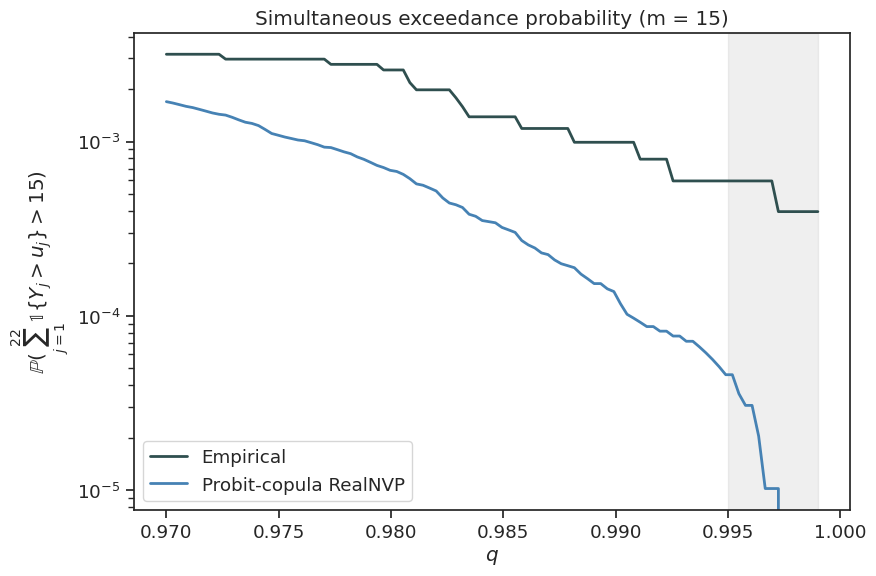

model                             LJPE   RMSLE_p
Probit-copula RealNVP           1.4446    1.5314


In [85]:
# --- Simultaneous exceedance probability: baseline normalizing flow vs empirical ---
# Same construction as the GPDFlow cells: the copula flow represents the
# conditional exceedance-cluster distribution, so its unconditional probability
# is P(cluster) * P(event | cluster) (CLAUDE.md Sec 2.4). Only the normalizing
# flow model is shown here; the full cross-model overlay is in the final cell.
p_cluster_bl = n_slice / samples_origin.shape[0]

m_fixed = 15
q_grid = np.linspace(0.97, 0.999, 100)

emp_probs_cmp = np.array(
    [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed) for q in q_grid]
)
flow_bl_probs = np.array([
    p_cluster_bl
    * cf.simultaneous_exceedance_probability(flow_baseline_raw, q, m_fixed, X_ref=samples_origin)
    for q in q_grid
])

plt.figure(figsize=(9, 6))
plt.plot(q_grid, emp_probs_cmp, color='darkslategray', lw=2, label='Empirical')
plt.plot(q_grid, flow_bl_probs, color='steelblue', lw=2, label='Probit-copula RealNVP')
plt.axvspan(0.995, q_grid.max(), color='gray', alpha=0.12)  # extrapolation region
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}(\sum_{{j=1}}^{{{dim}}}\mathbb{{1}}\{{Y_j>u_j\}} > {m_fixed})$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/simultaneous_exceedance_comparison.pdf', bbox_inches='tight')
plt.show()

# --- Quantitative exceedance-probability error, restricted to the data-supported
#     range (q <= 0.995). The copula flow has no EVT extrapolation guarantee, so
#     higher levels are plotted (shaded above) but not scored.
mask_q = q_grid <= 0.995


def _err(probs):
    p_hat = np.asarray(probs)[mask_q]
    p_true = emp_probs_cmp[mask_q]
    ok = p_true > 0
    return cf.ljpe(p_hat[ok], p_true[ok]), cf.rmsle_p(p_hat[ok], p_true[ok])


rows = [('Probit-copula RealNVP', *_err(flow_bl_probs))]

print(f'{"model":28s}  {"LJPE":>8s}  {"RMSLE_p":>8s}')
for name, a, b in rows:
    print(f'{name:28s}  {a:8.4f}  {b:8.4f}')


### Traditional mGPD comparison

#### Parametric mGPD: T-representation with a fixed generator family

The GPDFlow fits above replace the mGPD generator by a normalizing flow. The
classical alternative (Kiriliouk-Rootzen-Segers-Wadsworth) keeps the generator
**parametric**: write the standardized spectral vector as $S = T - \max(T)$ and
give $T$ a fixed distributional form. The standardized-mGPD density is then

$$h(z) = \mathbb{1}\{\max(z) > 0\}\, e^{-\max(z)} \int_{-\infty}^{\infty} f_T(z + s\,\mathbf{1})\, ds ,$$

and the observational-scale density multiplies this by the marginal Jacobian
$\prod_j (\sigma_j + \gamma_j x_j)^{-1}$ with $z = g_{\text{std}}(x;\sigma,\gamma)$
(CLAUDE.md 3.4). The 1-D integral over the common shift $s$ is evaluated by the
trapezoidal rule with a log-sum-exp stabiliser, exactly as in
`GPDFlow.py::T_mGPD_NF`.

Five generator families are fit: independent **Gumbel**, independent **reverse
Gumbel**, independent **reverse exponential**, independent **log-gamma**, and a
**multivariate Gaussian** generator. All generator parameters *and* the marginal
$(\sigma,\gamma)$ are learnable and estimated by stochastic-gradient maximum
likelihood on the same seed-1234 training split used elsewhere in the notebook;
one generator location per family is pinned to $0$ because $S=T-\max(T)$ is
shift-invariant. The family with the smallest **AIC** (training-set
log-likelihood, penalised by the number of identified free parameters) is carried
forward and evaluated on pairwise $\chi$, pairwise $\omega$ and the
simultaneous-exceedance probability, matching the GPDFlow diagnostics.

In [99]:
# ============================================================================
# Parametric mGPD  --  T-representation with a fixed parametric generator
# ============================================================================
# Same mGPD skeleton as GPDFlow, but the generator T is one of five parametric
# families instead of a normalizing flow.  The ParametricMGPD class and its
# fitting / model-selection helpers now live in parametric_mGPD.py, with the
# public + internal API aligned to GPDFlow.py::T_mGPD_NF (log_integral_f_T,
# log_prob_T_mGPD_std, loss_components keys, sample() signature, ...).  See that
# module docstring for the standardized-mGPD log-density and the trapezoid +
# log-sum-exp shift integral.
import importlib
import parametric_mGPD
importlib.reload(parametric_mGPD)  # pick up edits without a kernel restart
from parametric_mGPD import (
    ParametricMGPD,
    GENERATORS,
    fit_parametric_mgpd,
    support_mask,
)


In [87]:
# --- Fit all five generator families on the training split (seed 1234) --------
_param_train, _param_val = train_samples, val_samples
dim = _param_train.shape[1]

param_models, param_val_nll, param_hist = {}, {}, {}
for _gen in GENERATORS:
    print(f'Fitting parametric mGPD generator: {_gen}')
    _m, _v, _h = fit_parametric_mgpd(_gen, _param_train, _param_val, device,
                                     epochs=300, batch_size=256, seed=1234)
    param_models[_gen], param_val_nll[_gen], param_hist[_gen] = _m, _v, _h
    print(f'  -> best validation NLL: {_v:.4f}\n')

Fitting parametric mGPD generator: gumbel


  [gumbel    ] ep   0  batch loss     91.241   val NLL    32.513   (best    32.513)
  [gumbel    ] ep  50  batch loss     22.484   val NLL    22.385   (best    22.385)
  [gumbel    ] ep 100  batch loss     23.179   val NLL    22.219   (best    22.214)
  [gumbel    ] ep 150  batch loss     22.117   val NLL    22.186   (best    22.160)
  [gumbel    ] ep 200  batch loss     22.723   val NLL    22.158   (best    22.142)
  [gumbel    ] ep 235  batch loss     30.748   val NLL    22.149   (best    22.142)
  -> best validation NLL: 22.1425

Fitting parametric mGPD generator: rev_gumbel
  [rev_gumbel] ep   0  batch loss     82.540   val NLL    29.077   (best    29.077)
  [rev_gumbel] ep  50  batch loss     23.869   val NLL    21.691   (best    21.663)
  [rev_gumbel] ep 100  batch loss     23.205   val NLL    21.456   (best    21.456)
  [rev_gumbel] ep 150  batch loss     21.832   val NLL    21.402   (best    21.293)
  [rev_gumbel] ep 200  batch loss     21.206   val NLL    21.558   (best    21.

In [88]:
# --- Model selection by AIC (training-set log-likelihood) --------------------
# AIC = 2k - 2*loglik, loglik summed over the training rows that lie inside every
# family's fitted GPD marginal support (so all families are scored on the same
# rows).  A generator that cannot represent a row's standardized spectrum
# (notably the reverse-exponential generator, hard support t <= mu) assigns it
# near-zero density; each such row's log-density is floored at FLOOR = -1000 so a
# handful of pathological rows cannot send the sum to -inf, but the row still
# counts fully against that family's AIC.  `n_floored` reports how many rows were
# floored -- a large value flags a family that genuinely does not fit this data.
import pandas as pd

FLOOR = -1000.0
_tr = torch.tensor(np.asarray(_param_train), dtype=torch.float32, device=device)
_va = torch.tensor(np.asarray(_param_val), dtype=torch.float32, device=device)

_lp_tr, _sup_tr, _lp_va, _sup_va = {}, {}, {}, {}
for g, m in param_models.items():
    with torch.no_grad():
        _lp_tr[g] = m.log_prob(_tr)
        _lp_va[g] = m.log_prob(_va)
    _sup_tr[g] = support_mask(m, _tr)
    _sup_va[g] = support_mask(m, _va)

_common = torch.ones(_tr.shape[0], dtype=torch.bool, device=device)
for g in GENERATORS:
    _common &= _sup_tr[g]
print(f'training rows inside the common GPD marginal support of all five '
      f'families: {int(_common.sum())} / {_tr.shape[0]}\n')

_rows = []
for g in GENERATORS:
    lp = _lp_tr[g][_common]
    n_floored = int((lp < FLOOR).sum())
    loglik = float(lp.clamp(min=FLOOR).sum())
    k = param_models[g].n_params()
    vlp = _lp_va[g][_sup_va[g]].clamp(min=FLOOR)
    vnll = float(-vlp.mean()) if vlp.numel() else float('nan')
    _rows.append({'generator': g, 'k': k, 'loglik': loglik,
                  'AIC': 2 * k - 2 * loglik, 'val_nll': vnll,
                  'n_floored': n_floored})

aic_table = pd.DataFrame(_rows).sort_values('AIC').reset_index(drop=True)
aic_table['dAIC'] = aic_table['AIC'] - aic_table['AIC'].min()
aic_table = aic_table[['generator', 'k', 'loglik', 'AIC', 'dAIC',
                       'val_nll', 'n_floored']]
print(aic_table.to_string(index=False))

best_family = aic_table.loc[0, 'generator']
best_model = param_models[best_family]
print(f'\nAIC-best parametric generator: {best_family}')


training rows inside the common GPD marginal support of all five families: 652 / 1030

 generator   k        loglik          AIC        dAIC   val_nll  n_floored
  gaussian 318 -12958.579102 26553.158203    0.000000 19.465624          0
rev_gumbel  87 -14553.876953 29281.753906 2728.595703 21.251877          0
    gumbel  87 -15008.230469 30190.460938 3637.302734 22.142460          0
 log_gamma  87 -15081.769531 30337.539062 3784.380859 21.938816          0
   rev_exp  87 -16740.978516 33655.957031 7102.798828 25.116550          0

AIC-best parametric generator: gaussian


#### Evaluate the AIC-best parametric mGPD

Same conventions as the GPDFlow diagnostics: the empirical "truth" is estimated
at $p=0.97$ on `samples_origin`; model draws (all inside the exceedance cluster)
are evaluated at $p=0.90$. Both $\chi$ and $\omega$ estimators are rank-based and
hence invariant to the monotone per-margin transforms.

Traditional mGPD (gaussian)   tde_chi : 0.0460


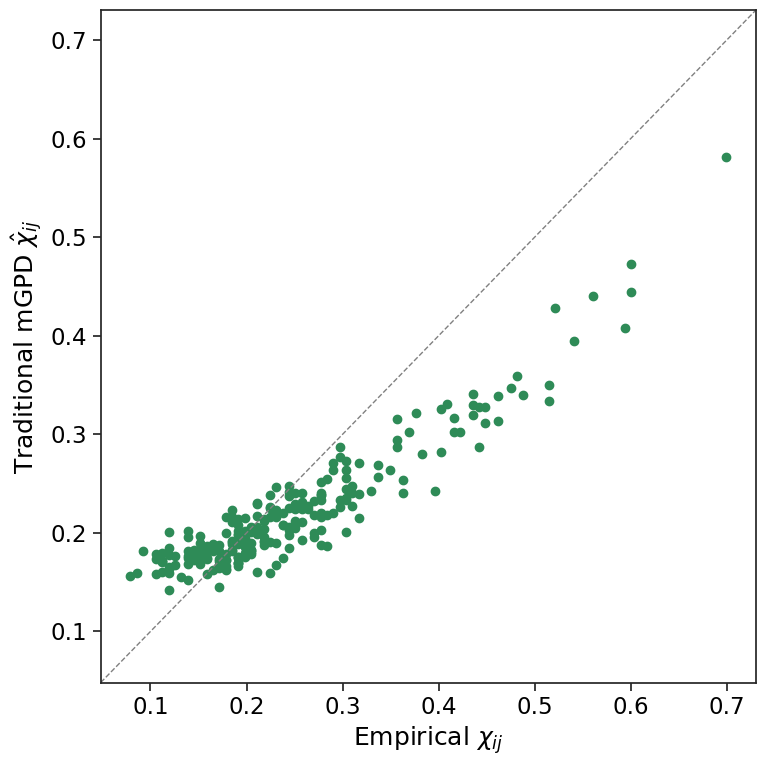

In [89]:
# --- Pairwise chi: empirical vs AIC-best parametric mGPD ---------------------
best_model.eval()
_xs, _, _ = best_model.sample(30000)
samples_par = _xs.cpu().numpy()
samples_par = samples_par[np.isfinite(samples_par).all(axis=1)]
samples_par_raw = samples_par + thres

chi_true_par = cf.pairwise_chi_from_data(samples_origin, p=0.97)
chi_hat_par = cf.pairwise_chi_from_data(samples_par, p=0.90)
print(f'Traditional mGPD ({best_family})   tde_chi : '
      f'{cf.tde_chi(chi_hat_par, chi_true_par):.4f}')

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_par[iu], chi_hat_par[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'Traditional mGPD $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_chi_traditional.pdf', bbox_inches='tight')
plt.show()

Traditional mGPD (gaussian)   tde_omega : 0.0442


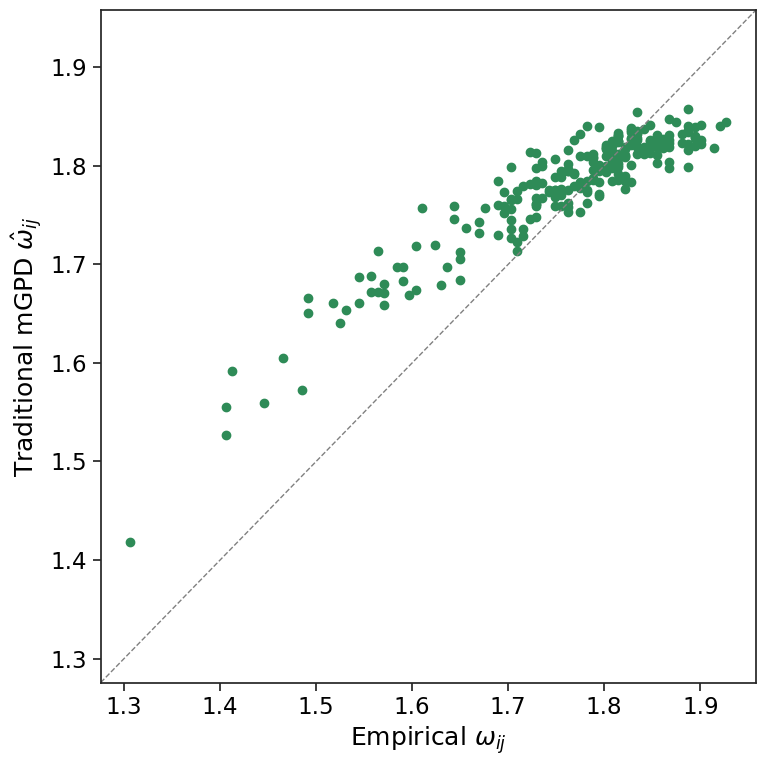

In [90]:
# --- Pairwise omega: empirical vs AIC-best parametric mGPD ------------------
omega_true_par = cf.pairwise_omega_from_data(samples_origin, p=0.97)
omega_hat_par = cf.pairwise_omega_from_data(samples_par, p=0.90)
print(f'Traditional mGPD ({best_family})   tde_omega : '
      f'{cf.tde_chi(omega_hat_par, omega_true_par):.4f}')

iu = np.triu_indices(dim, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(omega_true_par[iu], omega_hat_par[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\omega_{ij}$', color='black')
ax.set_ylabel(r'Traditional mGPD $\hat{\omega}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_omega_traditional.pdf', bbox_inches='tight')
plt.show()

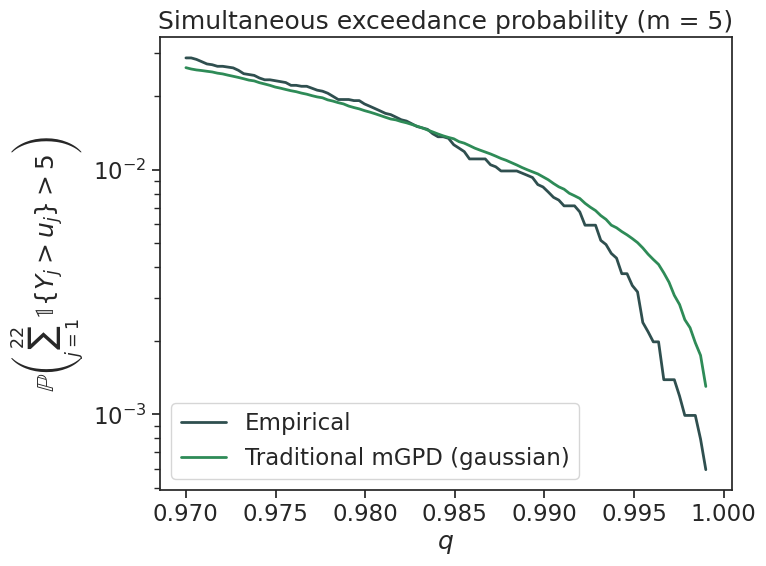

In [91]:
# --- Simultaneous exceedance probability: empirical vs AIC-best parametric mGPD
# The parametric mGPD represents only the conditional exceedance-cluster
# distribution, so the unconditional probability is
#   P(event) = P(cluster) * P(event | cluster)                (CLAUDE.md Sec 2.4)
p_cluster = samples.shape[0] / samples_origin.shape[0]
m_fixed = 5
q_grid = np.linspace(0.97, 0.999, 100)

emp_probs_par = [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed)
                 for q in q_grid]
par_probs = [
    p_cluster * cf.simultaneous_exceedance_probability(
        samples_par_raw, q, m_fixed, X_ref=samples_origin)
    for q in q_grid
]

plt.figure(figsize=(8, 6))
plt.plot(q_grid, emp_probs_par, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(q_grid, par_probs, color='seagreen', linewidth=2,
         label=f'Traditional mGPD ({best_family})')
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim}}} \mathbb{{1}}\{{Y_j > u_j\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()

### Traditional mGPD comparison standardized version

#### Parametric mGPD on the standardized scale

The parametric analogue of the two-stage GPDFlow fit (Stage 2): keep the
generator **parametric** (the same five families as the previous section), but
fit it on the **standardized** exceedances `samples_2s` -- the stage-1
univariate-GPD standardization `Z = g_std(X - u; sigma_j, gamma_j)` re-thresholded
at 0 -- with the marginal `(sigma, gamma)` pinned to `(1, 0)`
(`fix_margin=True`). Only the dependence structure is estimated here; the
marginal tail behaviour is carried by the stage-1 fit
`(uni_sigma_2s, uni_gamma_2s)`.

Model selection (AIC on the training-set log-likelihood) and the diagnostics
(pairwise chi, pairwise omega, simultaneous-exceedance probability) follow the
previous section exactly. Model draws are mapped back to the observational scale
through the inverse stage-1 standardization before the simultaneous-exceedance
comparison against `samples_origin`.

In [100]:
# --- Fit all five generator families on the STANDARDIZED training split -------
# Same call as the previous section, but on samples_2s (stage-1 standardized
# exceedances, threshold 0) with fix_margin=True -- the parametric counterpart
# of the two-stage `model_2s` GPDFlow fit.
dim_2s = samples_2s.shape[1]
_param_train_2s, _param_val_2s = train_samples_2s, val_samples_2s

param_models_2s, param_val_nll_2s, param_hist_2s = {}, {}, {}
for _gen in GENERATORS:
    print(f'Fitting standardized parametric mGPD generator: {_gen}')
    _m, _v, _h = fit_parametric_mgpd(_gen, _param_train_2s, _param_val_2s, device,
                                     epochs=300, batch_size=256, seed=1234,
                                     fix_margin=True)
    param_models_2s[_gen], param_val_nll_2s[_gen], param_hist_2s[_gen] = _m, _v, _h
    print(f'  -> best validation NLL: {_v:.4f}\n')


Fitting standardized parametric mGPD generator: gumbel


  [gumbel    ] ep   0  batch loss    113.042   val NLL   336.420   (best   336.420)
  [gumbel    ] ep  50  batch loss     96.502   val NLL   199.292   (best   199.292)
  [gumbel    ] ep 100  batch loss     95.524   val NLL   163.050   (best   163.050)
  [gumbel    ] ep 150  batch loss     90.063   val NLL   147.046   (best   147.046)
  [gumbel    ] ep 200  batch loss     98.704   val NLL   139.956   (best   139.956)
  [gumbel    ] ep 250  batch loss     97.230   val NLL   136.674   (best   136.674)
  [gumbel    ] ep 299  batch loss     89.169   val NLL   136.073   (best   136.073)
  -> best validation NLL: 136.0730

Fitting standardized parametric mGPD generator: rev_gumbel
  [rev_gumbel] ep   0  batch loss     80.541   val NLL    90.245   (best    90.245)
  [rev_gumbel] ep  50  batch loss     64.110   val NLL    72.329   (best    72.329)
  [rev_gumbel] ep 100  batch loss     58.617   val NLL    68.499   (best    68.499)
  [rev_gumbel] ep 150  batch loss     67.273   val NLL    67.054 

In [ ]:
# --- Model selection by AIC, standardized fit -------------------------------
# fix_margin=True makes support_mask vacuous (sigma=1, gamma=0), so -- unlike the
# free-margin AIC cell -- there is no marginal-support prefilter.  Instead score
# every family on the common set of training rows that *all* families represent
# with a finite, non-pathological log-density (> ROW_MIN); rows that no family can
# place are dropped from every family's score (and counted as n_excl).  mean_ll
# and val_nll are reported per row so they are comparable regardless of the size
# of the common set.
import pandas as pd

ROW_MIN = -50.0
_tr2 = torch.tensor(np.asarray(_param_train_2s), dtype=torch.float32, device=device)
_va2 = torch.tensor(np.asarray(_param_val_2s), dtype=torch.float32, device=device)

_lp_tr2, _lp_va2 = {}, {}
for g, m in param_models_2s.items():
    with torch.no_grad():
        _lp_tr2[g] = m.log_prob(_tr2)
        _lp_va2[g] = m.log_prob(_va2)

_ok_tr2 = {g: torch.isfinite(_lp_tr2[g]) & (_lp_tr2[g] > ROW_MIN) for g in GENERATORS}
_common2 = torch.ones(_tr2.shape[0], dtype=torch.bool, device=device)
for g in GENERATORS:
    _common2 &= _ok_tr2[g]
n_common2 = int(_common2.sum())
print(f'standardized training rows represented by all five families '
      f'(log-density > {ROW_MIN:g}): {n_common2} / {_tr2.shape[0]}\n')

_rows2 = []
for g in GENERATORS:
    lp = _lp_tr2[g][_common2]
    k = param_models_2s[g].n_params()
    loglik = float(lp.sum())
    vlp = _lp_va2[g]
    vlp = torch.where(torch.isfinite(vlp) & (vlp > ROW_MIN), vlp,
                      torch.full_like(vlp, ROW_MIN))
    _rows2.append({'generator': g, 'k': k,
                   'mean_ll': float(lp.mean()),
                   'AIC': 2 * k - 2 * loglik,
                   'val_nll': float(-vlp.mean()),
                   'n_excl': int((~_ok_tr2[g]).sum())})

aic_table_2s = pd.DataFrame(_rows2).sort_values('AIC').reset_index(drop=True)
aic_table_2s['dAIC'] = aic_table_2s['AIC'] - aic_table_2s['AIC'].min()
aic_table_2s = aic_table_2s[['generator', 'k', 'mean_ll', 'AIC', 'dAIC',
                             'val_nll', 'n_excl']]
print(aic_table_2s.to_string(index=False))

best_family_2s = aic_table_2s.loc[0, 'generator']
best_model_2s = param_models_2s[best_family_2s]
print(f'\nAIC-best standardized parametric generator: {best_family_2s}')


#### Evaluate the AIC-best standardized parametric mGPD

Same conventions as the other diagnostics: the empirical "truth" is estimated at
$p = 0.97$ on `samples_origin`; model draws (all inside the exceedance cluster)
are evaluated at $p = 0.90$. Pairwise $\chi$ and $\omega$ are rank-based and so
are computed directly on the standardized draws; the simultaneous-exceedance
comparison first maps the draws back to the raw observational scale.

Standardized mGPD (log_gamma)   tde_chi : 0.0877


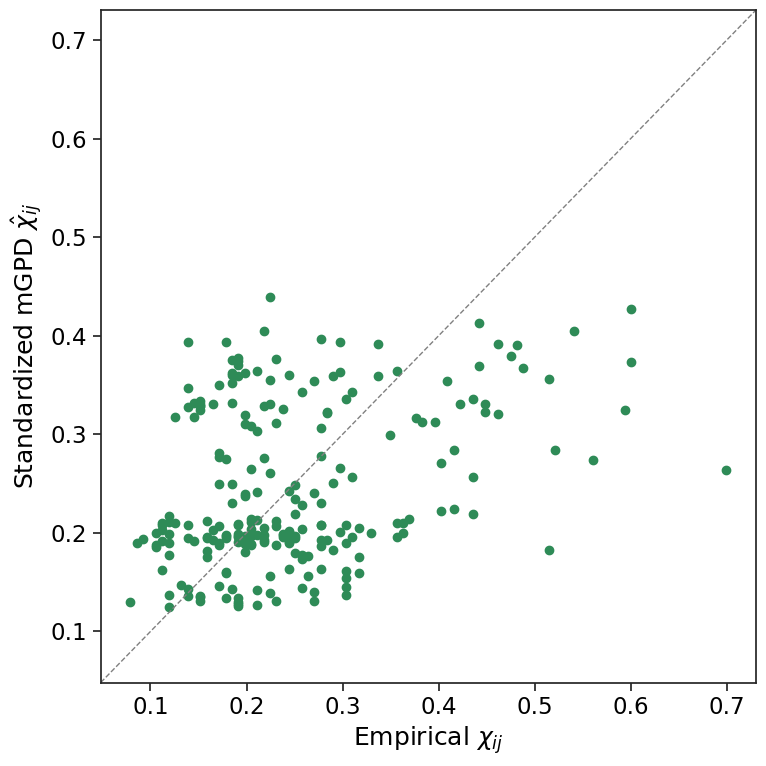

In [102]:
# --- Pairwise chi: empirical vs AIC-best standardized parametric mGPD --------
best_model_2s.eval()
_xs2, _, _ = best_model_2s.sample(30000)
samples_par_2s = _xs2.cpu().numpy()
samples_par_2s = samples_par_2s[np.isfinite(samples_par_2s).all(axis=1)]

# Map the standardized draws back to the observational scale via the inverse
# stage-1 standardization (same formula as the two-stage GPDFlow cell), using the
# stage-1 marginal GPD fit (uni_sigma_2s, uni_gamma_2s) and raw threshold thres_2s.
_gz = np.isclose(uni_gamma_2s, 0.0)
_gs = np.where(_gz, 1.0, uni_gamma_2s)
samples_par_2s_raw = thres_2s + np.where(
    _gz,
    uni_sigma_2s * samples_par_2s,
    uni_sigma_2s * (np.exp(_gs * samples_par_2s) - 1) / _gs,
)

chi_true_par_2s = cf.pairwise_chi_from_data(samples_origin, p=0.97)
chi_hat_par_2s = cf.pairwise_chi_from_data(samples_par_2s, p=0.90)
print(f'Standardized mGPD ({best_family_2s})   tde_chi : '
      f'{cf.tde_chi(chi_hat_par_2s, chi_true_par_2s):.4f}')

iu = np.triu_indices(dim_2s, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(chi_true_par_2s[iu], chi_hat_par_2s[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\chi_{ij}$', color='black')
ax.set_ylabel(r'Standardized mGPD $\hat{\chi}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_chi_traditional_std.pdf', bbox_inches='tight')
plt.show()


Standardized mGPD (log_gamma)   tde_omega : 0.0877


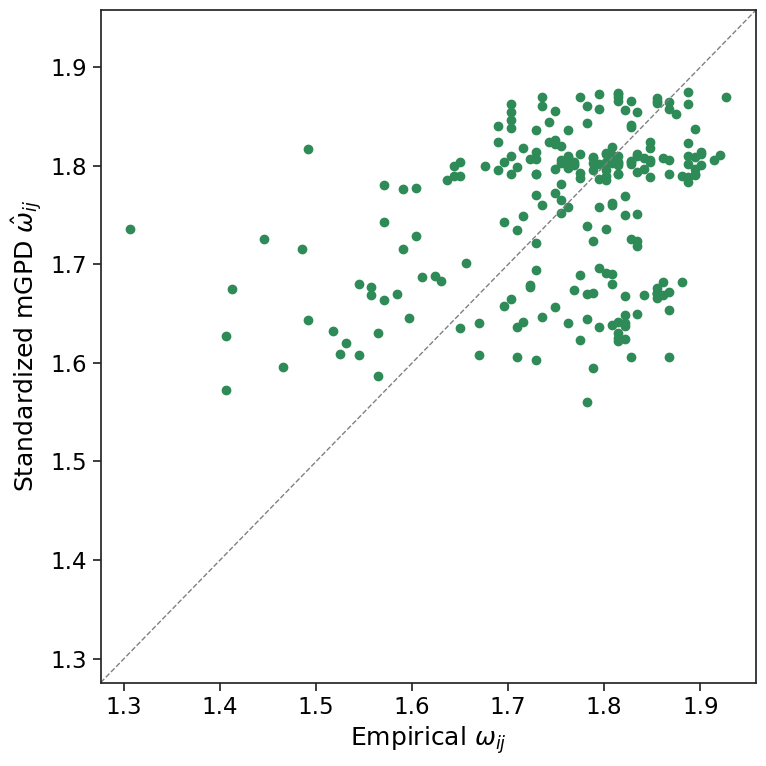

In [103]:
# --- Pairwise omega: empirical vs AIC-best standardized parametric mGPD ------
omega_true_par_2s = cf.pairwise_omega_from_data(samples_origin, p=0.97)
omega_hat_par_2s = cf.pairwise_omega_from_data(samples_par_2s, p=0.90)
print(f'Standardized mGPD ({best_family_2s})   tde_omega : '
      f'{cf.tde_chi(omega_hat_par_2s, omega_true_par_2s):.4f}')

iu = np.triu_indices(dim_2s, k=1)
sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(omega_true_par_2s[iu], omega_hat_par_2s[iu], color='seagreen')
lims = [min(*ax.get_xlim(), *ax.get_ylim()), max(*ax.get_xlim(), *ax.get_ylim())]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical $\omega_{ij}$', color='black')
ax.set_ylabel(r'Standardized mGPD $\hat{\omega}_{ij}$', color='black')
ax.tick_params(axis='both', labelcolor='black')
fig.tight_layout()
fig.savefig(dir_out + 'Plots/pairwise_omega_traditional_std.pdf', bbox_inches='tight')
plt.show()


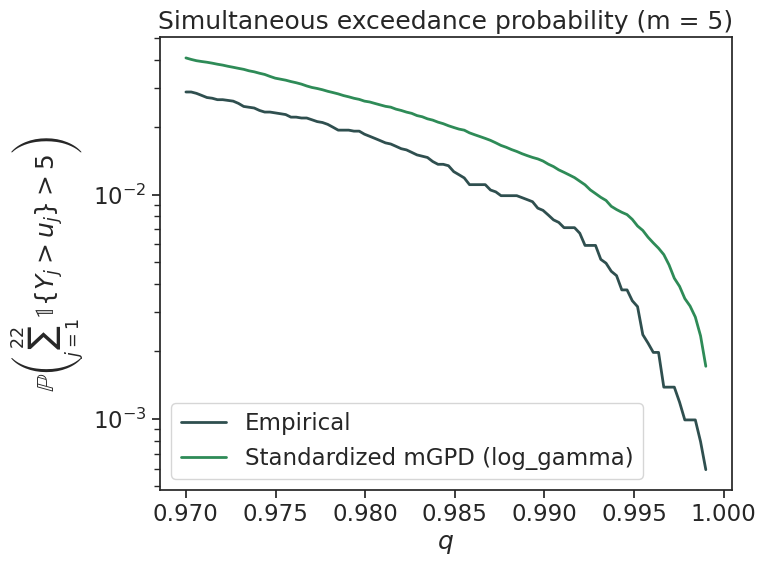

In [104]:
# --- Simultaneous exceedance probability: empirical vs standardized parametric mGPD
# Draws are mapped back to the raw observational scale (samples_par_2s_raw, built
# in the chi cell). The parametric mGPD represents only the conditional
# exceedance-cluster distribution, so the unconditional probability is
#   P(event) = P(cluster) * P(event | cluster)                (CLAUDE.md Sec 2.4)
# with P(cluster) the standardized-scale joint-exceedance rate.
p_cluster_2s = samples_2s.shape[0] / samples_origin.shape[0]
m_fixed = 5
q_grid = np.linspace(0.97, 0.999, 100)

emp_probs_par_2s = [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed)
                    for q in q_grid]
par_probs_2s = [
    p_cluster_2s * cf.simultaneous_exceedance_probability(
        samples_par_2s_raw, q, m_fixed, X_ref=samples_origin)
    for q in q_grid
]

plt.figure(figsize=(8, 6))
plt.plot(q_grid, emp_probs_par_2s, color='darkslategray', linewidth=2, label='Empirical')
plt.plot(q_grid, par_probs_2s, color='seagreen', linewidth=2,
         label=f'Standardized mGPD ({best_family_2s})')
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}\left(\sum_{{j=1}}^{{{dim_2s}}} \mathbb{{1}}\{{Y_j > u_j\}} > {m_fixed}\right)$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.show()


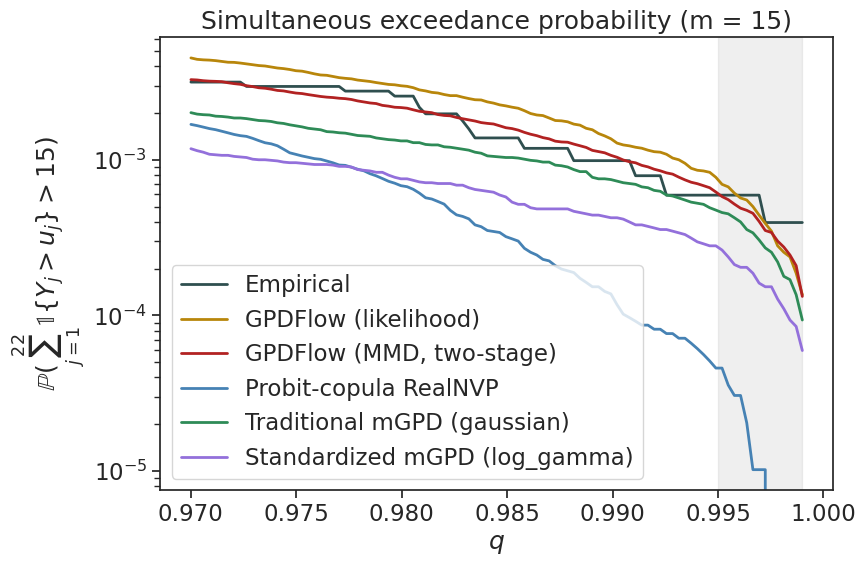

model                                 LJPE   RMSLE_p
GPDFlow (likelihood)                0.3326    0.3568
GPDFlow (MMD, two-stage)            0.1209    0.1446
Probit-copula RealNVP               1.4446    1.5314
Traditional mGPD (gaussian)         0.3960    0.4435
Standardized mGPD (log_gamma)       0.9598    0.9773


In [105]:
# --- Cross-model comparison.  Every simultaneous-exceedance curve is recomputed
#     here from its stored raw samples using THIS cell's m_fixed, so all models
#     (and the empirical estimate) are compared at the same m.  Models not fit in
#     this session are skipped via globals().get(...).
m_fixed = 15
q_grid = np.linspace(0.97, 0.999, 100)


def _sep(X_raw, p_cluster):
    return np.array([
        p_cluster * cf.simultaneous_exceedance_probability(
            X_raw, q, m_fixed, X_ref=samples_origin)
        for q in q_grid
    ])


emp_probs_cmp = np.array(
    [cf.simultaneous_exceedance_probability(samples_origin, q, m_fixed) for q in q_grid])

# (label, raw-sample var, cluster-probability var, colour)
_specs = [
    ('GPDFlow (likelihood)',     'samples_simu_raw',    'p_cluster',    'darkgoldenrod'),
    ('GPDFlow (MMD, two-stage)', 'samples_simu_2s_raw', 'p_cluster_2s', 'firebrick'),
    ('Probit-copula RealNVP',    'flow_baseline_raw',   'p_cluster_bl', 'steelblue'),
]

_curves = []
for _name, _xkey, _pkey, _col in _specs:
    _x = globals().get(_xkey)
    _p = globals().get(_pkey)
    if _x is not None and _p is not None:
        _curves.append((_name, _sep(_x, _p), _col))

par_probs = None
if 'samples_par_raw' in globals():
    p_cluster_par = samples.shape[0] / samples_origin.shape[0]
    par_probs = _sep(samples_par_raw, p_cluster_par)

par_probs_std = None
if 'samples_par_2s_raw' in globals() and 'samples_2s' in globals():
    p_cluster_std = samples_2s.shape[0] / samples_origin.shape[0]
    par_probs_std = _sep(samples_par_2s_raw, p_cluster_std)

plt.figure(figsize=(9, 6))
plt.plot(q_grid, emp_probs_cmp, color='darkslategray', lw=2, label='Empirical')
for _name, _v, _col in _curves:
    plt.plot(q_grid, _v, color=_col, lw=2, label=_name)
if par_probs is not None:
    plt.plot(q_grid, par_probs, color='seagreen', lw=2,
             label=f'Traditional mGPD ({best_family})')
if par_probs_std is not None:
    plt.plot(q_grid, par_probs_std, color='mediumpurple', lw=2,
             label=f'Standardized mGPD ({best_family_2s})')
plt.axvspan(0.995, q_grid.max(), color='gray', alpha=0.12)
plt.yscale('log')
plt.xlabel(r'$q$')
plt.ylabel(rf'$\mathbb{{P}}(\sum_{{j=1}}^{{{dim}}}\mathbb{{1}}\{{Y_j>u_j\}} > {m_fixed})$')
plt.title(f'Simultaneous exceedance probability (m = {m_fixed})')
plt.legend()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/simultaneous_exceedance_comparison_traditional.pdf',
            bbox_inches='tight')
plt.show()

# --- Quantitative error, restricted to the data-supported range (q <= 0.995) --
mask_q = q_grid <= 0.995


def _err_par(probs):
    p_hat = np.asarray(probs)[mask_q]
    p_true = emp_probs_cmp[mask_q]
    ok = p_true > 0
    return cf.ljpe(p_hat[ok], p_true[ok]), cf.rmsle_p(p_hat[ok], p_true[ok])


_tbl = [(_name, *_err_par(_v)) for _name, _v, _ in _curves]
if par_probs is not None:
    _tbl.append((f'Traditional mGPD ({best_family})', *_err_par(par_probs)))
if par_probs_std is not None:
    _tbl.append((f'Standardized mGPD ({best_family_2s})', *_err_par(par_probs_std)))

print(f'{"model":32s}  {"LJPE":>8s}  {"RMSLE_p":>8s}')
for _name, _a, _b in _tbl:
    print(f'{_name:32s}  {_a:8.4f}  {_b:8.4f}')
